<a href="https://colab.research.google.com/github/Mahesh527784/DataAnalyst/blob/main/FinalAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import pandas as pd , numpy as np

In [35]:
univ = pd.read_csv('/content/Universities.csv')
univ1 = pd.read_csv('/content/Universities.csv')

**. Remove all records with missing measurements from the dataset. **

In [36]:
univ.head()

,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.0,44.0,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.0
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,NaN,NaN,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,NaN
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.0
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,NaN,NaN,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,NaN
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,NaN,NaN,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.0


In [37]:
univ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              1302 non-null   object 
 1   State                     1302 non-null   object 
 2   Public (1)/ Private (2)   1302 non-null   int64  
 3   # appli. rec'd            1292 non-null   float64
 4   # appl. accepted          1291 non-null   float64
 5   # new stud. enrolled      1297 non-null   float64
 6   % new stud. from top 10%  1067 non-null   float64
 7   % new stud. from top 25%  1100 non-null   float64
 8   # FT undergrad            1299 non-null   float64
 9   # PT undergrad            1270 non-null   float64
 10  in-state tuition          1272 non-null   float64
 11  out-of-state tuition      1282 non-null   float64
 12  room                      981 non-null    float64
 13  board                     804 non-null    float64
 14  add. fee

In [38]:
univ.isnull().sum()



,0
College Name,0
State,0
Public (1)/ Private (2),0
# appli. rec'd,10
# appl. accepted,11
# new stud. enrolled,5
% new stud. from top 10%,235
% new stud. from top 25%,202
# FT undergrad,3
# PT undergrad,32


In [39]:
print(univ1.duplicated().sum())

0


In [40]:
# prompt: remove duplicate values

# Drop duplicate rows based on all columns
univ.drop_duplicates(inplace=True)

#To drop duplicates based on specific column(s):
# univ.drop_duplicates(subset=['Column1', 'Column2'], inplace=True)

print(univ.shape) # Print the shape to verify
univ.head()


(1302, 20)


,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.0,44.0,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.0
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,NaN,NaN,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,NaN
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.0,24.0,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.0
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,NaN,NaN,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,NaN
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,NaN,NaN,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.0


In [41]:
# prompt: Using dataframe univ: convert college name and state columns data type into  string

# Convert the 'College Name' column to string data type.
univ['College Name'] = univ['College Name'].astype(str)

# Convert the 'State' column to string data type.
univ['State'] = univ['State'].astype(str)


In [42]:
# prompt: replace null value in a column  with mean value of the column for every column in a dataset

for col in univ.columns:
    if univ[col].dtype in ['int64', 'float64']:
        mean_value = univ[col].mean()
        univ[col].fillna(mean_value, inplace=True)


<ipython-input-42-073f3c718548>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  univ[col].fillna(mean_value, inplace=True)


In [43]:
univ.head()


,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,in-state tuition,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate
0,Alaska Pacific University,AK,2,193.0,146.0,55.0,16.000000,44.00,249.0,869.0,7560.0,7560.0,1620.0,2500.0,130.0,800.0,1500.0,76.0,11.9,15.000000
1,University of Alaska at Fairbanks,AK,1,1852.0,1427.0,928.0,25.671978,52.35,3885.0,4519.0,1742.0,5226.0,1800.0,1790.0,155.0,650.0,2304.0,67.0,10.0,60.405316
2,University of Alaska Southeast,AK,1,146.0,117.0,89.0,4.000000,24.00,492.0,1849.0,1742.0,5226.0,2514.0,2250.0,34.0,500.0,1162.0,39.0,9.5,39.000000
3,University of Alaska at Anchorage,AK,1,2065.0,1598.0,1162.0,25.671978,52.35,6209.0,10537.0,1742.0,5226.0,2600.0,2520.0,114.0,580.0,1260.0,48.0,13.7,60.405316
4,Alabama Agri. & Mech. Univ.,AL,1,2817.0,1920.0,984.0,25.671978,52.35,3958.0,305.0,1700.0,3400.0,1108.0,1442.0,155.0,500.0,850.0,53.0,14.3,40.000000


In [44]:
univ.shape

(1302, 20)

In [45]:
univ.isnull().sum()

,0
College Name,0
State,0
Public (1)/ Private (2),0
# appli. rec'd,0
# appl. accepted,0
# new stud. enrolled,0
% new stud. from top 10%,0
% new stud. from top 25%,0
# FT undergrad,0
# PT undergrad,0


**2. For all the continuous measurements, run hierarchical clustering using complete linkage and Euclidean distance. Make sure to normalize the measurements. From the dendrogram, how many clusters seem reasonable for describing these data? **

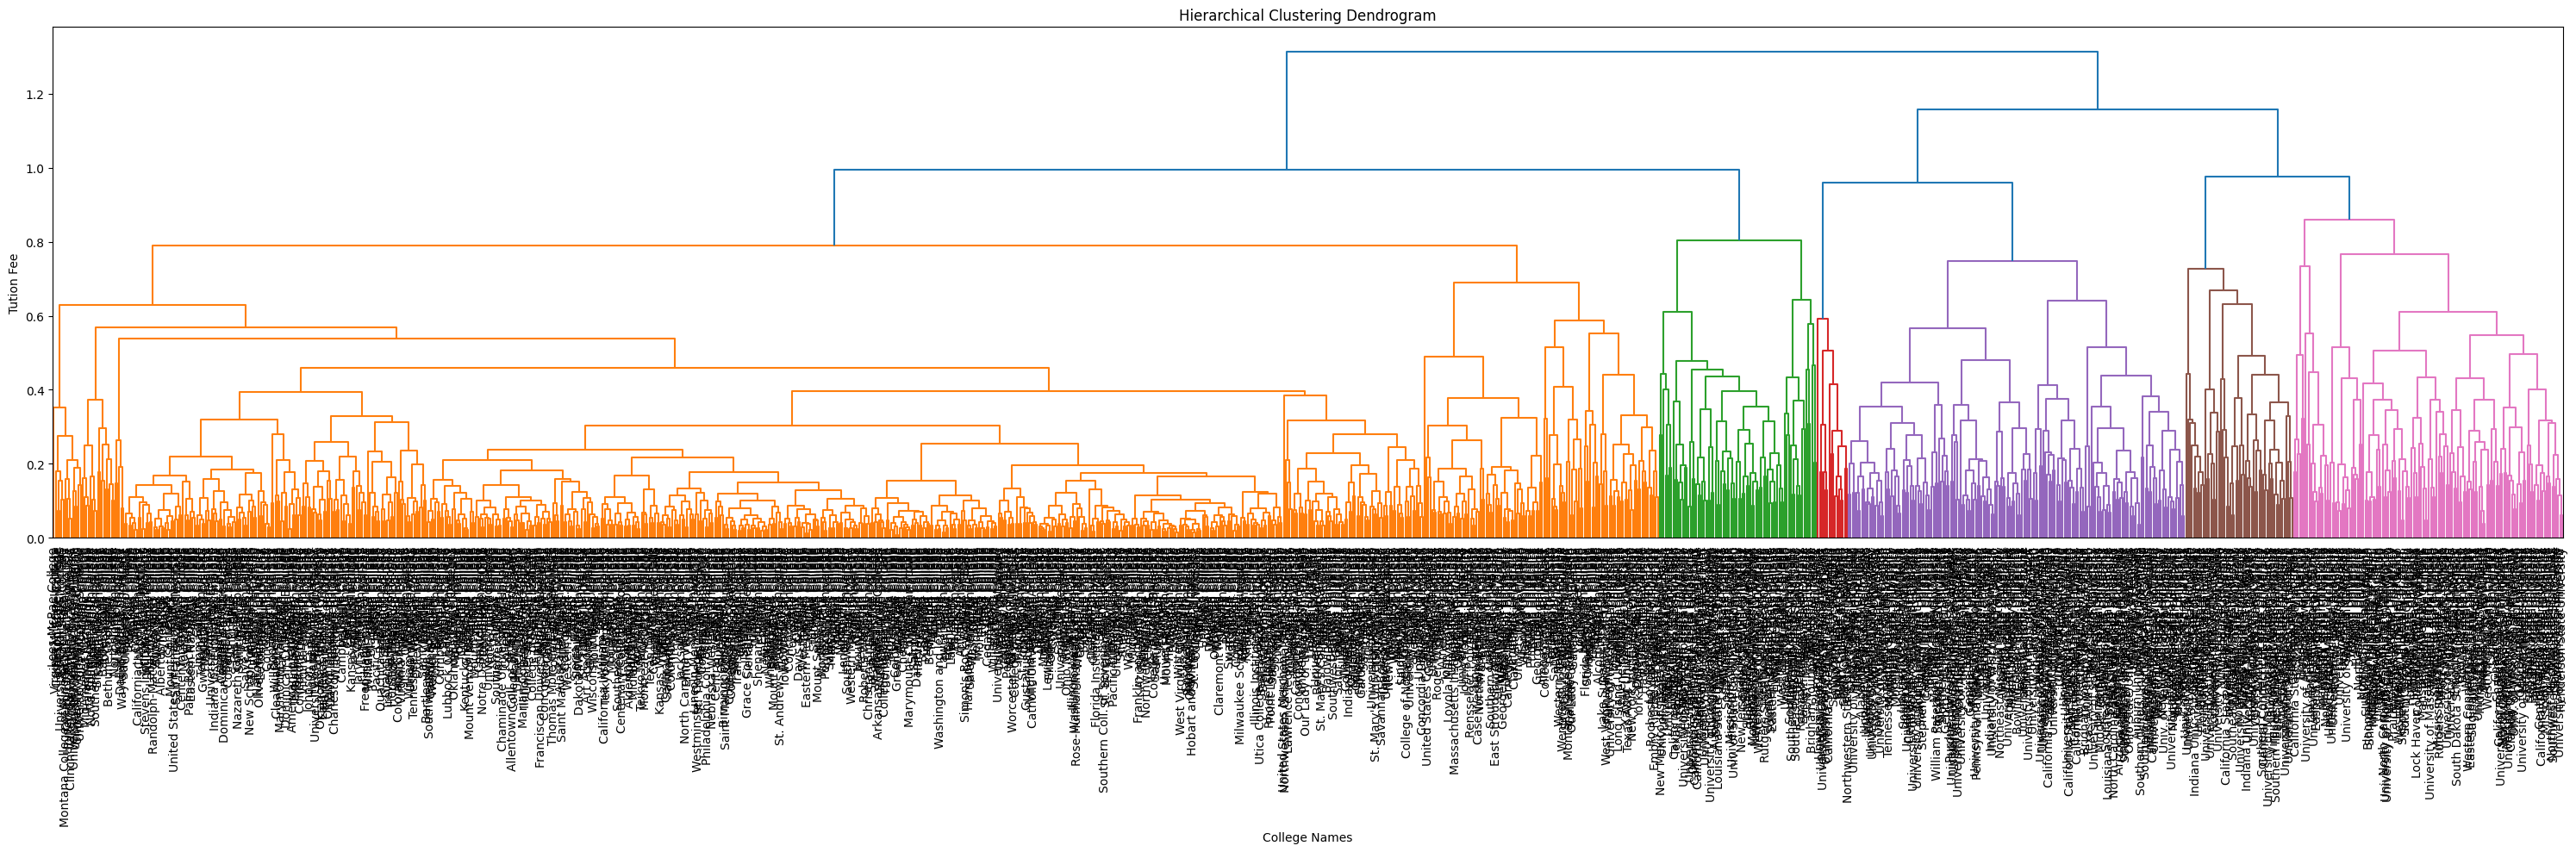

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import normalize
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Select only continuous features for clustering
continuous_features = univ.select_dtypes(include=['number'])

# Normalize the continuous features
normalized_data = normalize(continuous_features)

# Perform hierarchical clustering with complete linkage and Euclidean distance
mergings = linkage(normalized_data, method='complete', metric='euclidean')

# Plot the dendrogram with college names as labels
plt.figure(figsize=(30, 10))
dendrogram(mergings,
           labels=univ['College Name'].tolist(),  # Use college names as labels
           leaf_rotation=90,
           leaf_font_size=10,
           )
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('College Names')
plt.ylabel('In state Tution Fee')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

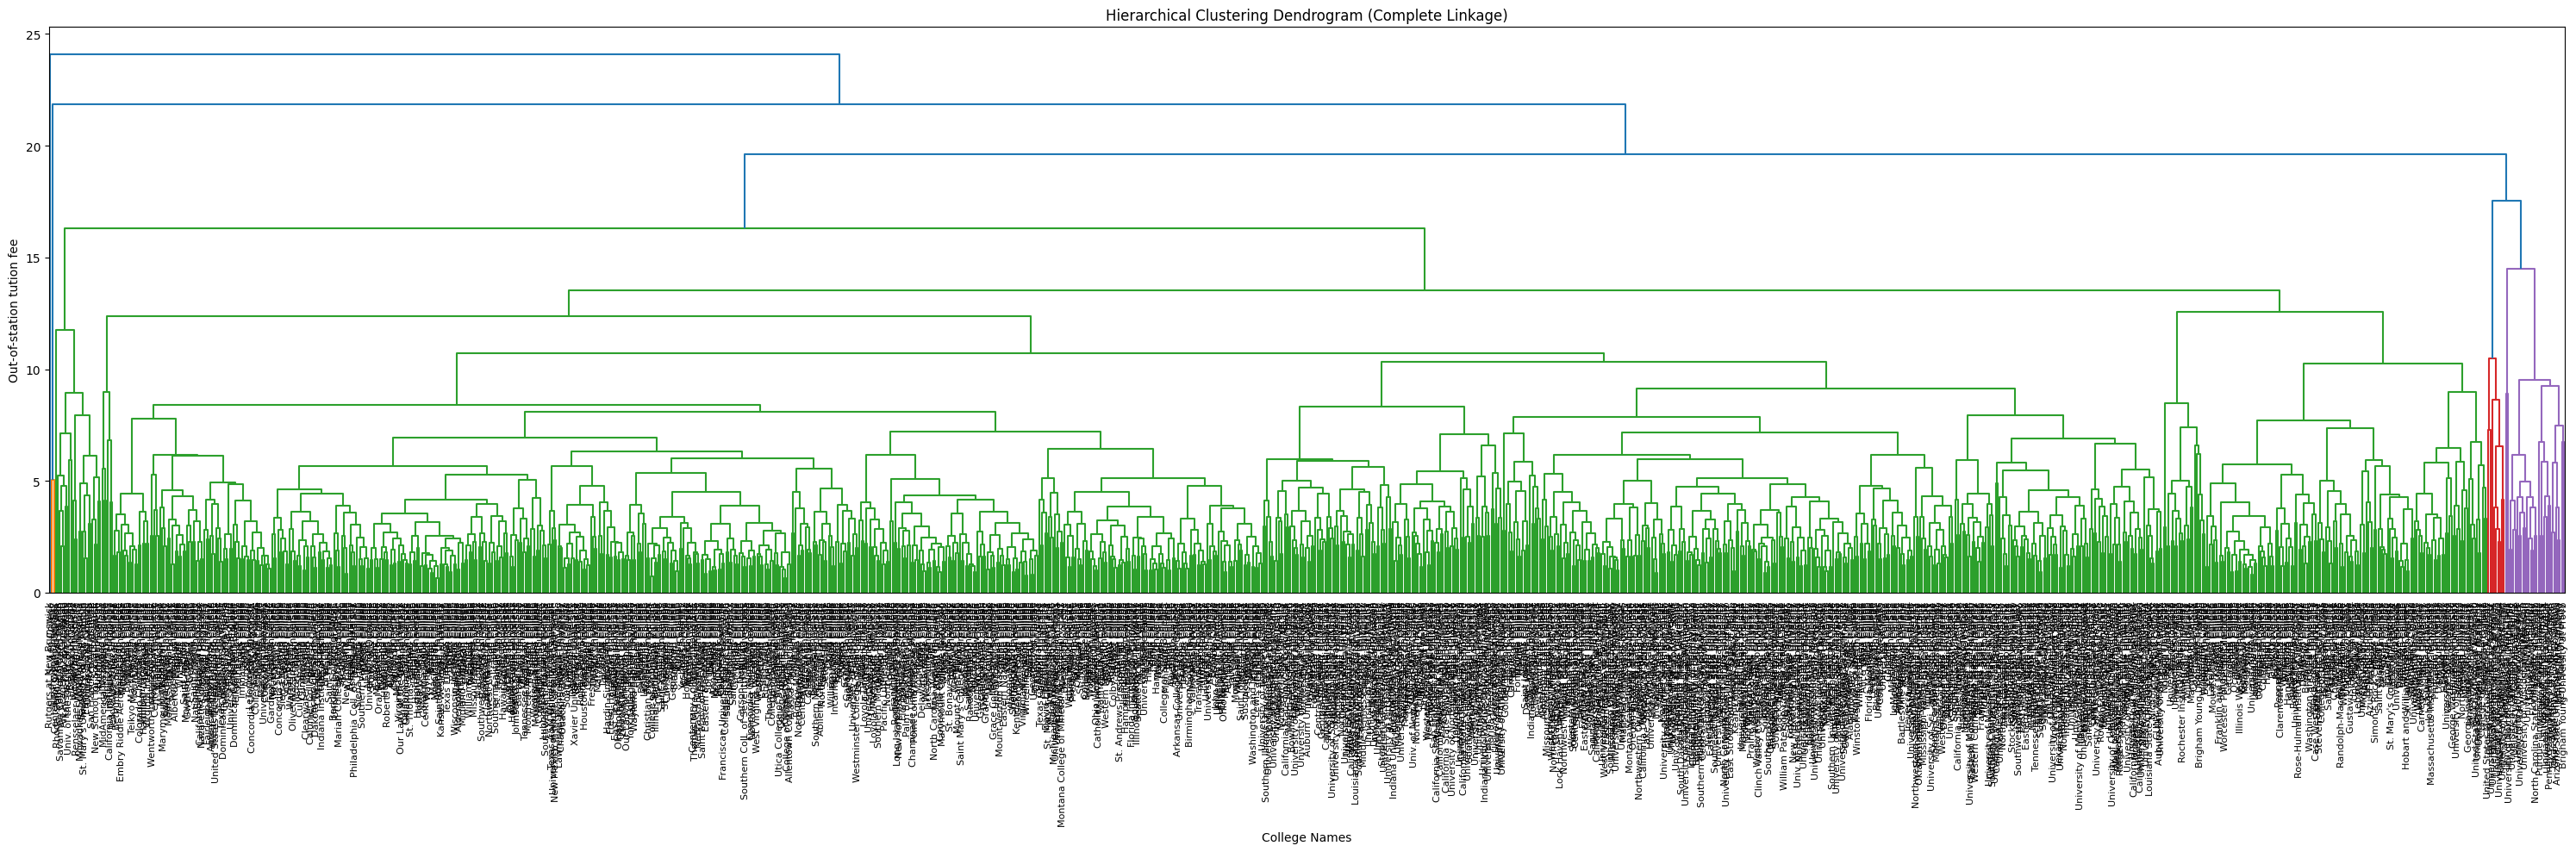

In [49]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Step 1: Select only continuous features for clustering
continuous_features = univ.select_dtypes(include=['number'])

# Step 2: Standardize (z-score normalize) the continuous features
scaler = StandardScaler()
normalized_data = scaler.fit_transform(continuous_features)

# Step 3: Perform hierarchical clustering with complete linkage and Euclidean distance
mergings = linkage(normalized_data, method='complete', metric='euclidean')

# Step 4: Plot the dendrogram with college names as labels
plt.figure(figsize=(30, 10))
dendrogram(mergings,
           labels=univ['College Name'].tolist(),  # Use college names as labels
           leaf_rotation=90,
           leaf_font_size=8)
plt.title('Hierarchical Clustering Dendrogram (Complete Linkage)')
plt.xlabel('College Names')
plt.ylabel('Out-of-station tution fee')
plt.tight_layout()  # Adjust layout to prevent label overlap
plt.show()


**Compare the summary statistics for each cluster and describe each cluster in this context (e.g., “Universities with high tuition, low acceptance rate…”). **

In [58]:
univ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   College Name              1302 non-null   object 
 1   State                     1302 non-null   object 
 2   Public (1)/ Private (2)   1302 non-null   int64  
 3   # appli. rec'd            1302 non-null   float64
 4   # appl. accepted          1302 non-null   float64
 5   # new stud. enrolled      1302 non-null   float64
 6   % new stud. from top 10%  1302 non-null   float64
 7   % new stud. from top 25%  1302 non-null   float64
 8   # FT undergrad            1302 non-null   float64
 9   # PT undergrad            1302 non-null   float64
 10  in-state tuition          1302 non-null   float64
 11  out-of-state tuition      1302 non-null   float64
 12  room                      1302 non-null   float64
 13  board                     1302 non-null   float64
 14  add. fee

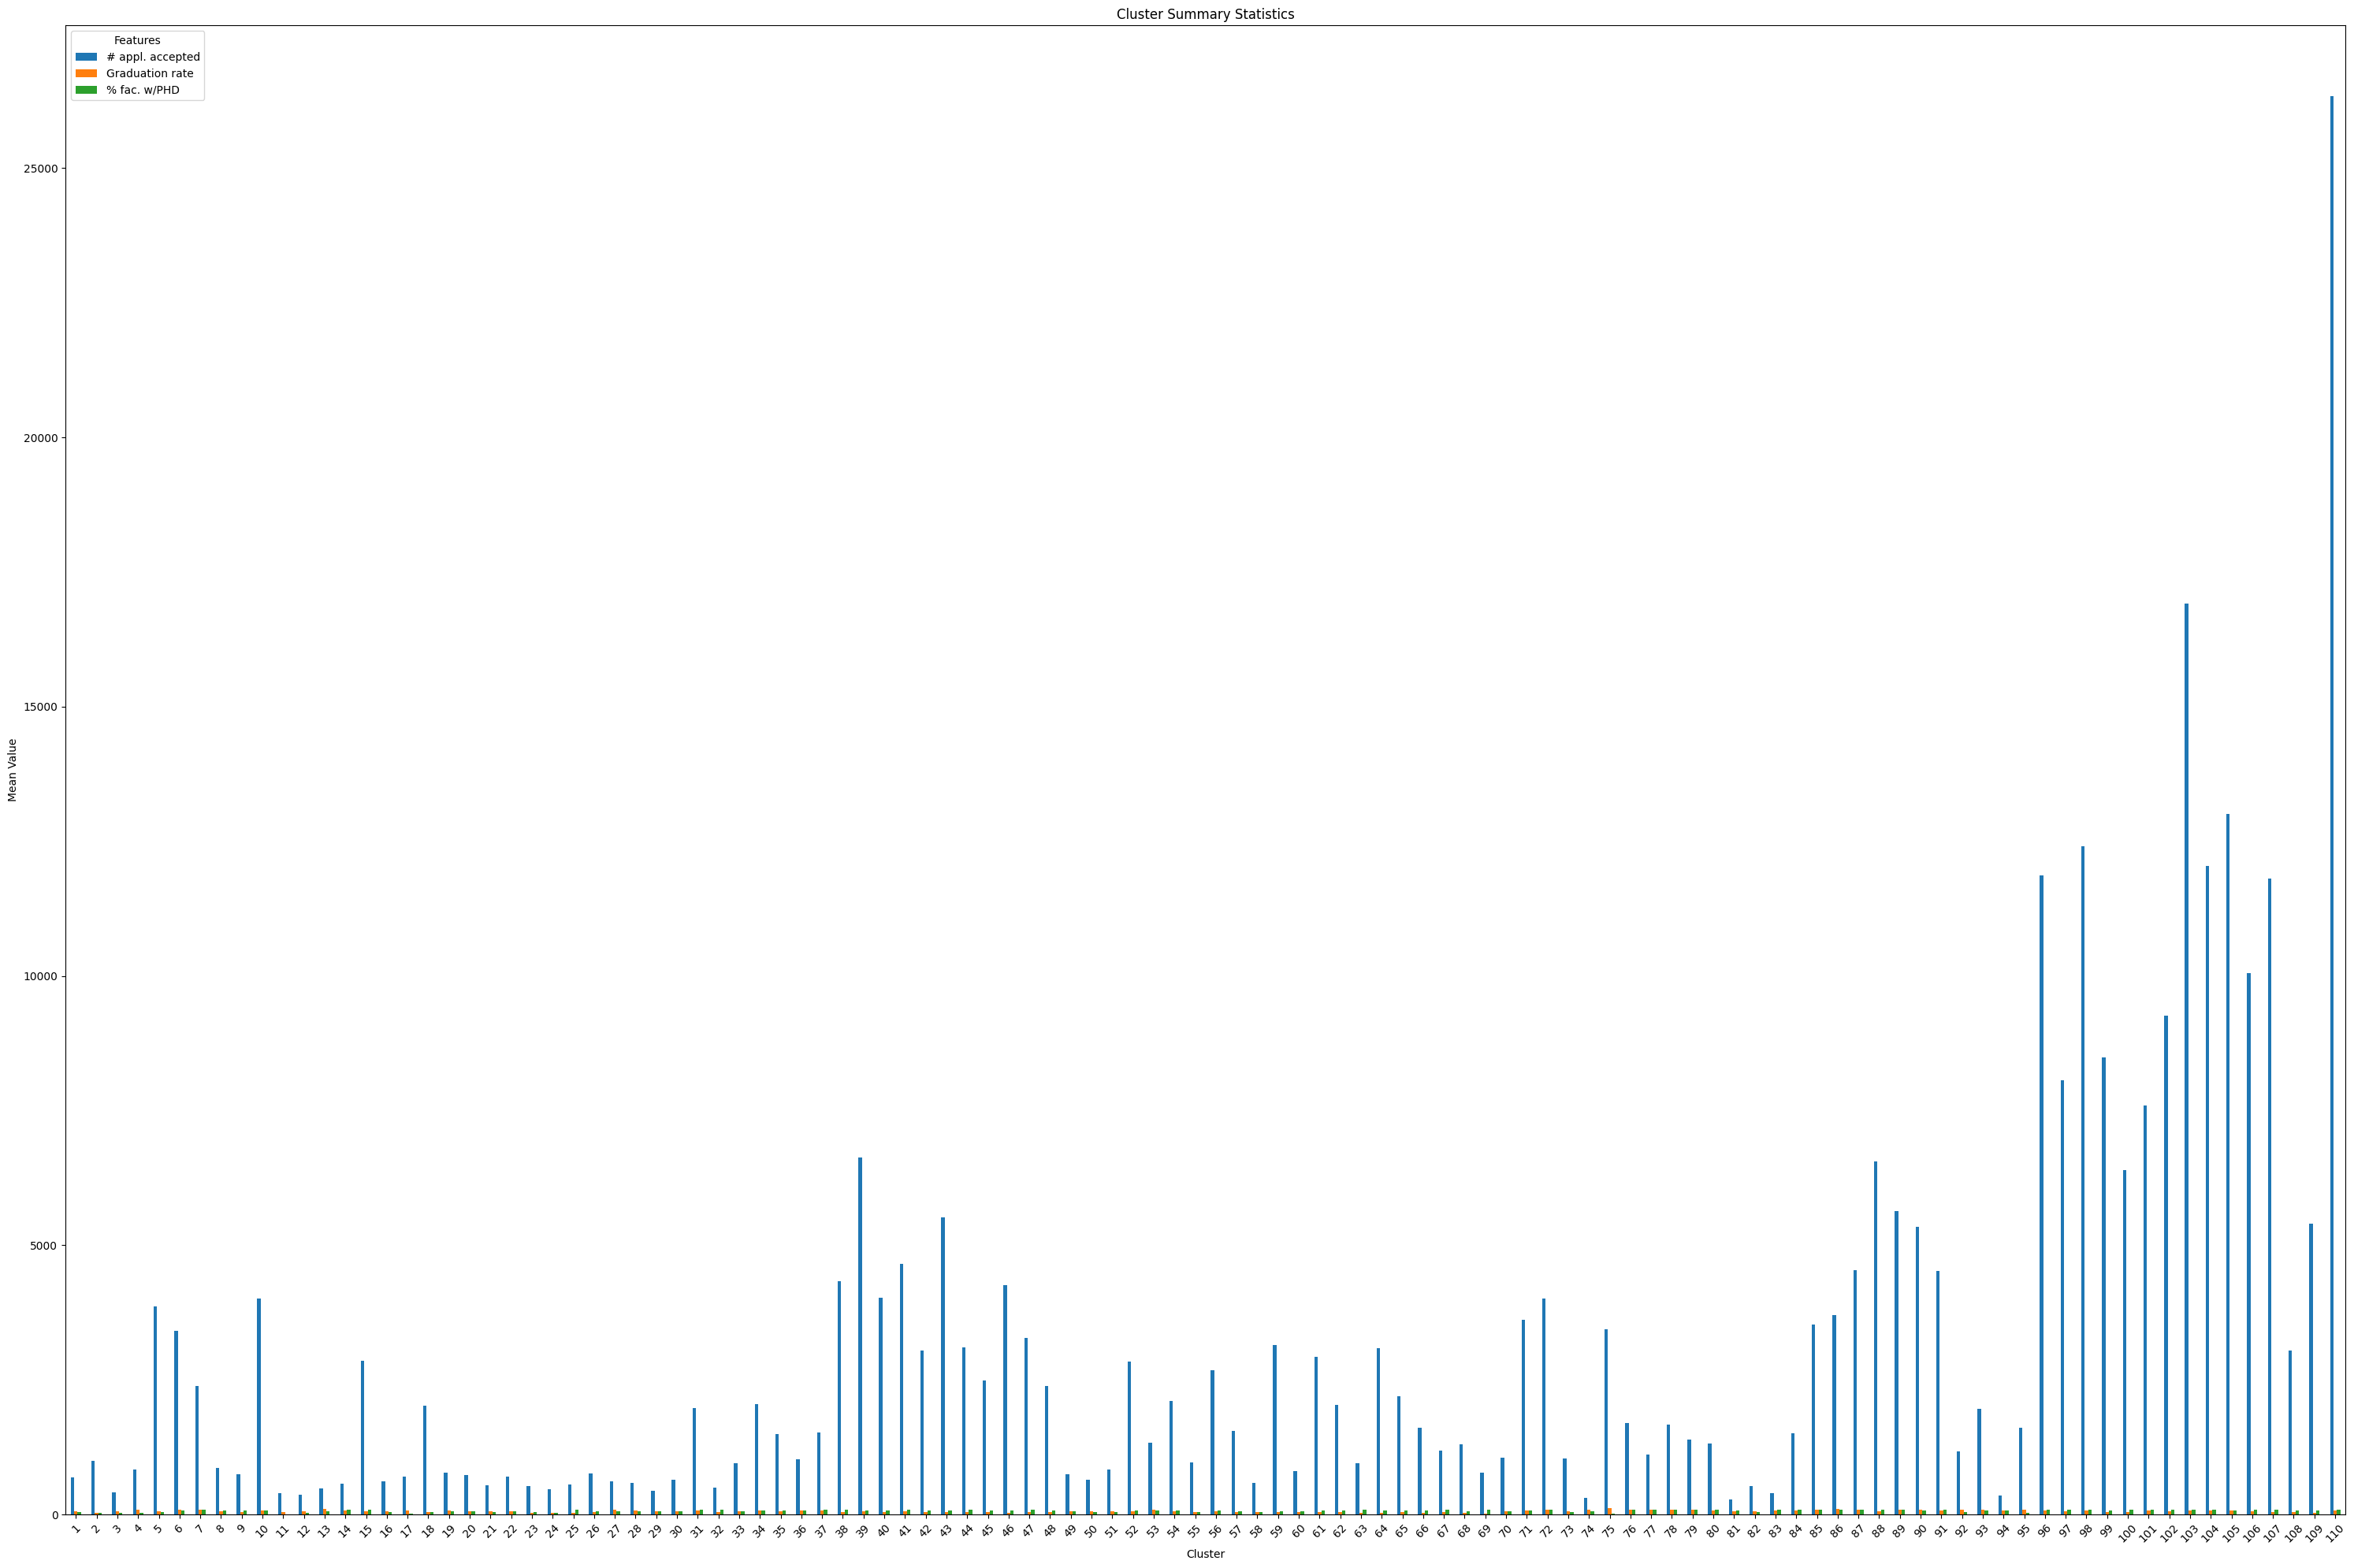

In [66]:
# prompt: univ.groupby('Cluster')[['# appl. accepted','Graduation rate','% fac. w/PHD']].mean()
# by using this statement print the heirarichal graph as taking the x-axis as the College Name

import matplotlib.pyplot as plt

# Assuming 'Cluster' column is already created (e.g., from previous clustering)
# If not, perform clustering and add the 'Cluster' column to the dataframe first.

cluster_summary = univ.groupby('Cluster')[['# appl. accepted','Graduation rate','% fac. w/PHD']].mean()

# Create a bar plot for each cluster
cluster_summary.plot(kind='bar', figsize=(30, 20))
plt.title('Cluster Summary Statistics')
plt.xlabel('Cluster')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.legend(title='Features')
plt.tight_layout()
plt.show()


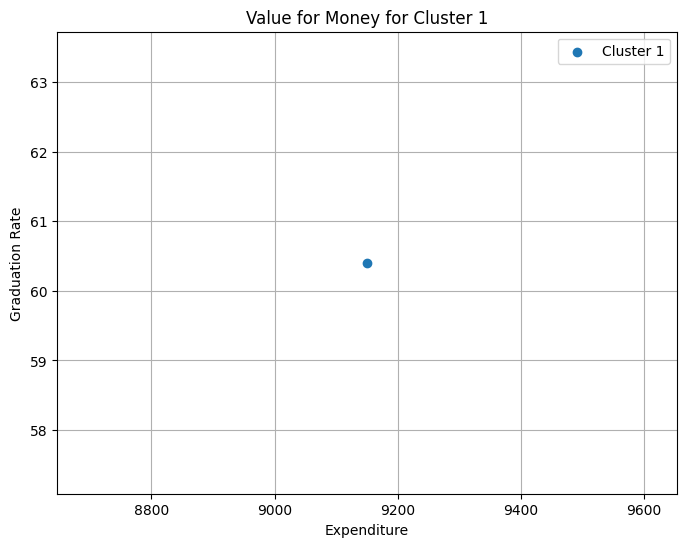

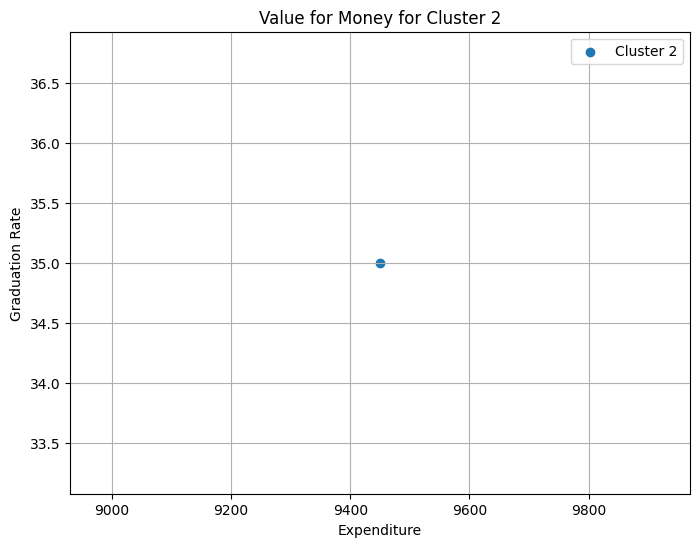

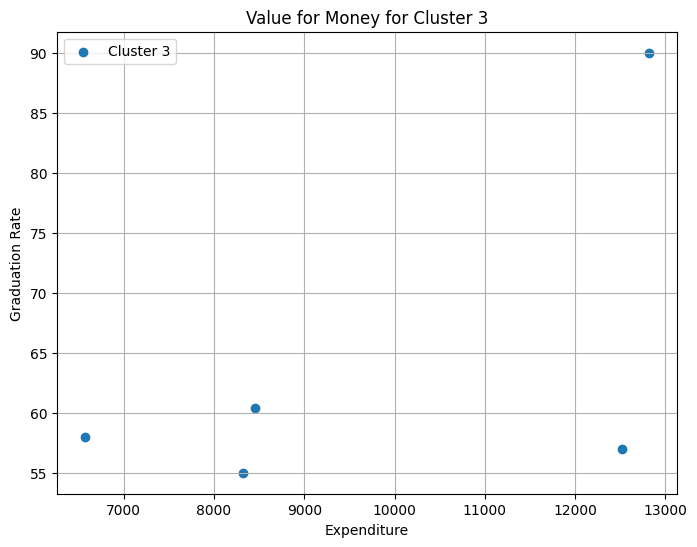

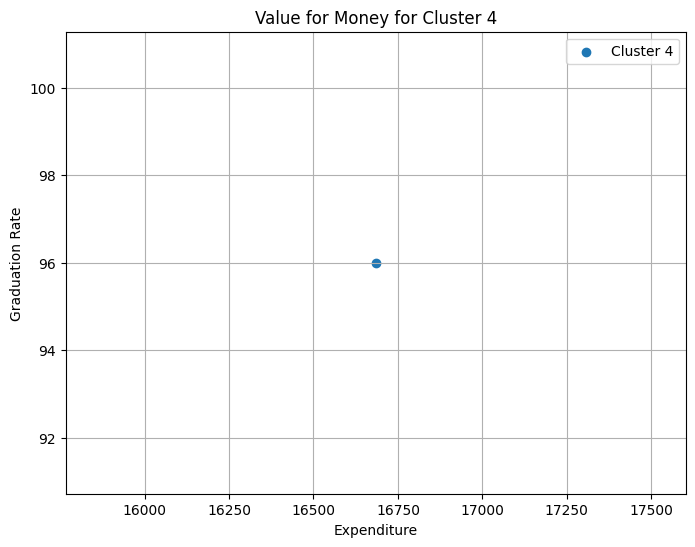

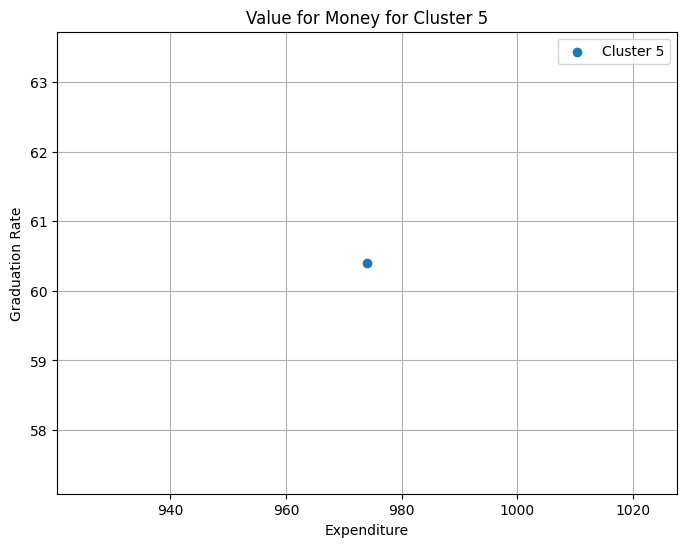

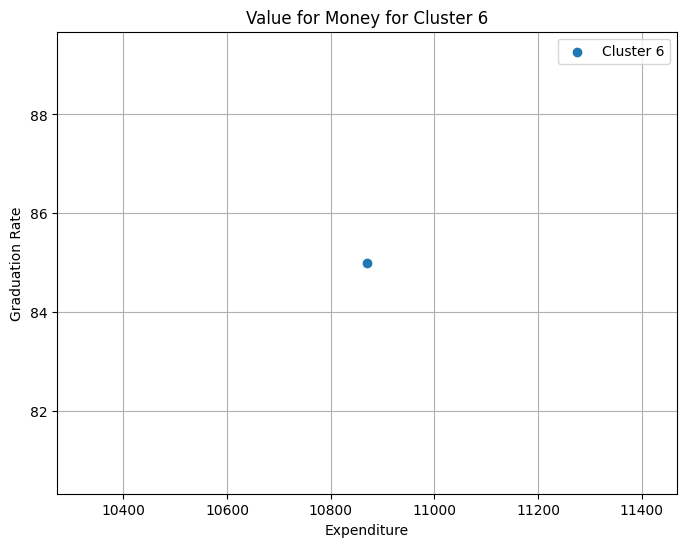

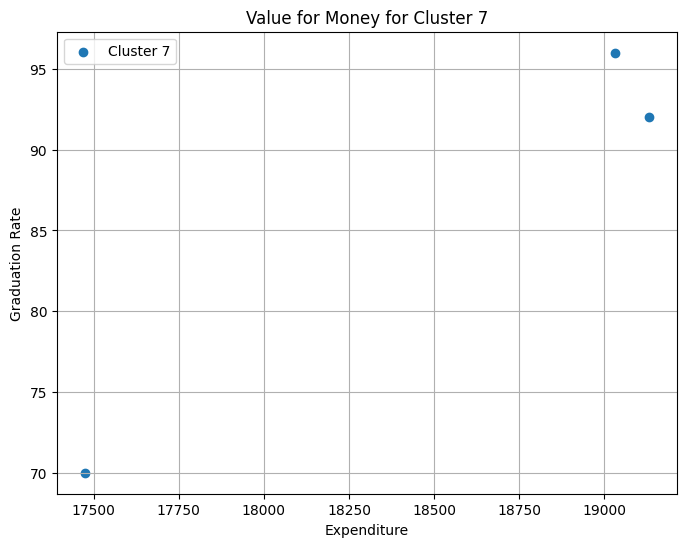

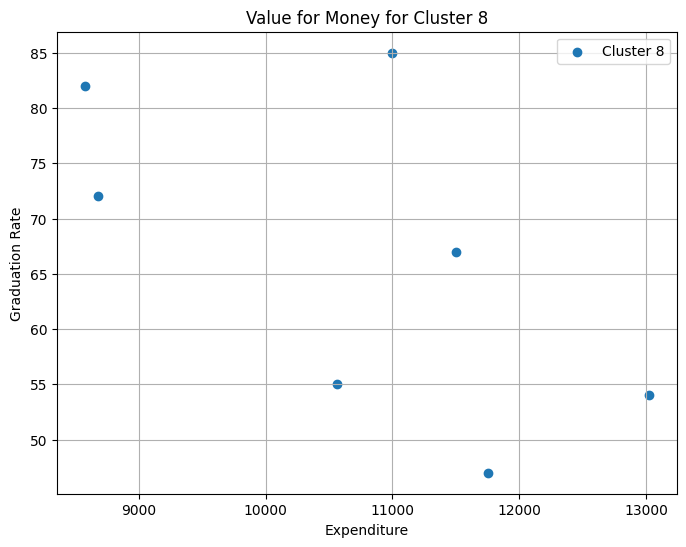

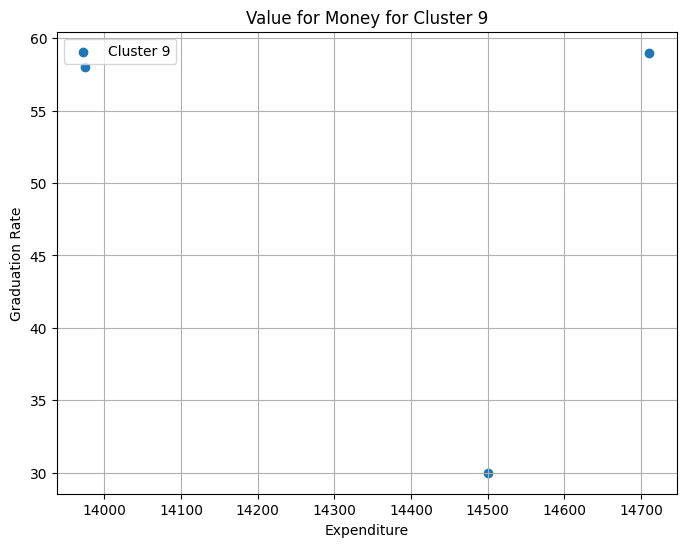

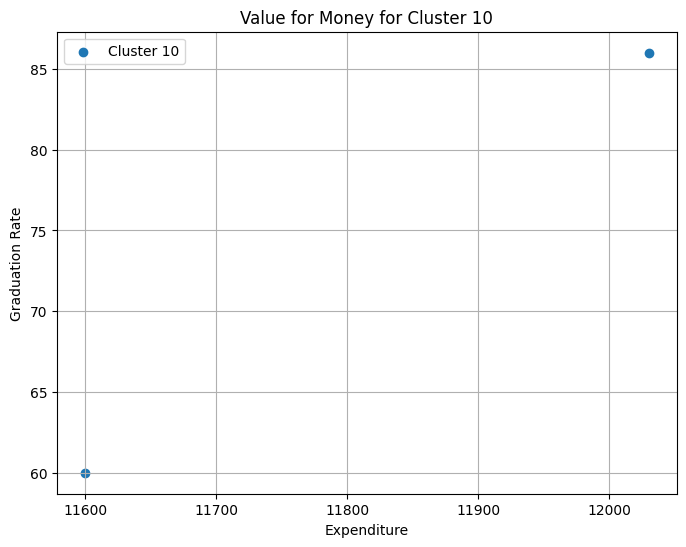

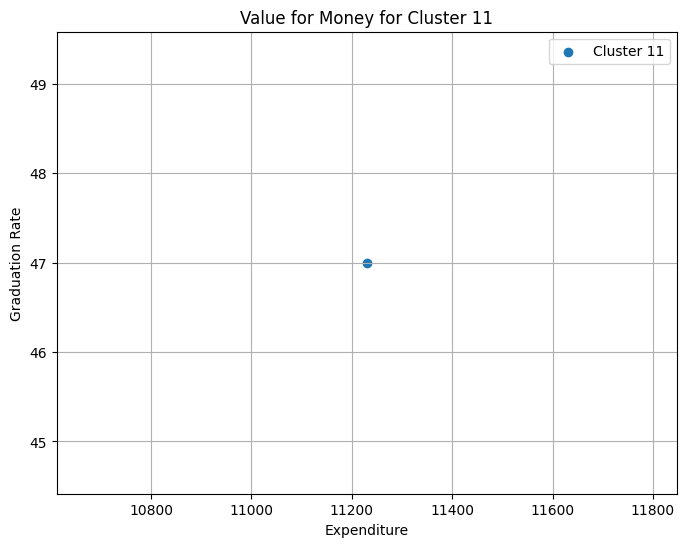

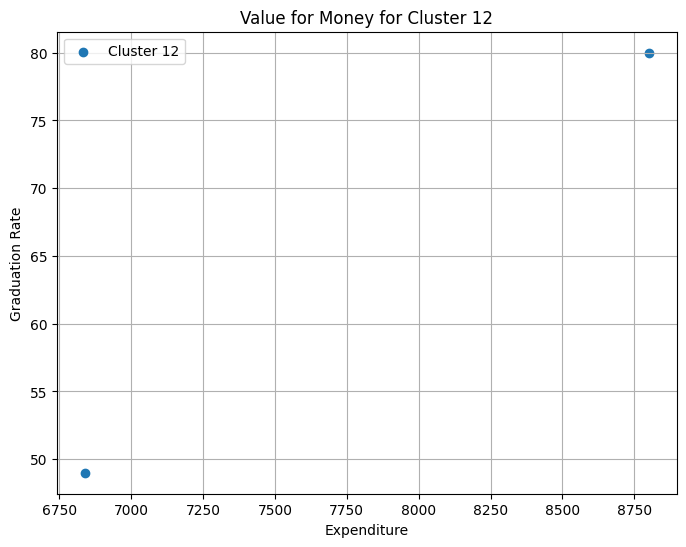

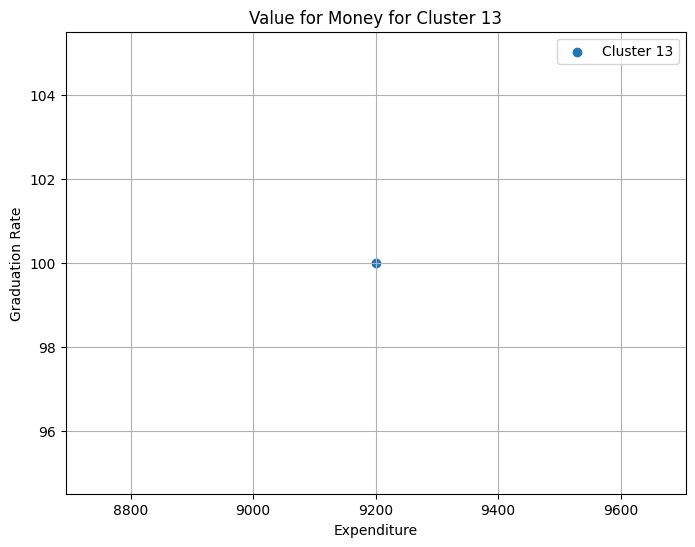

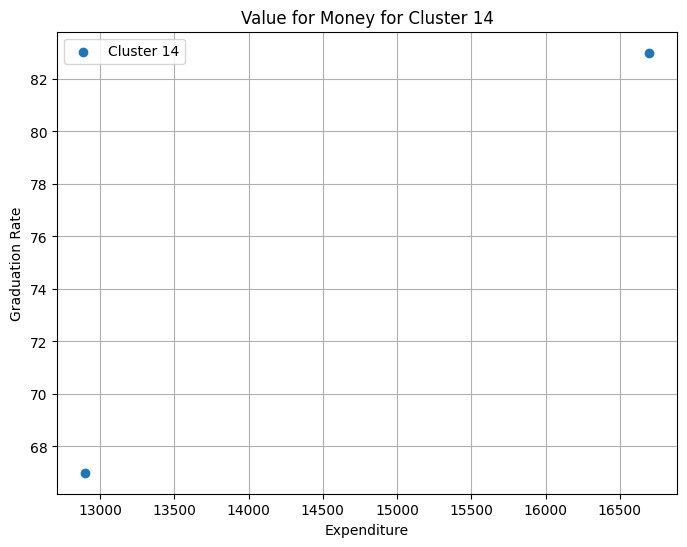

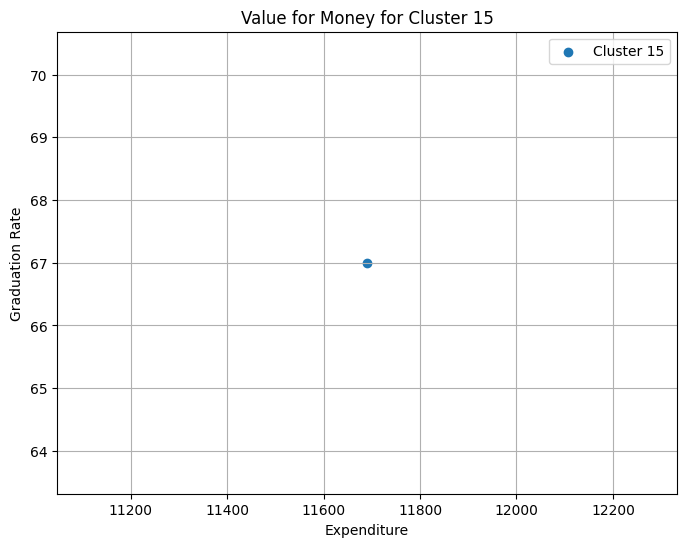

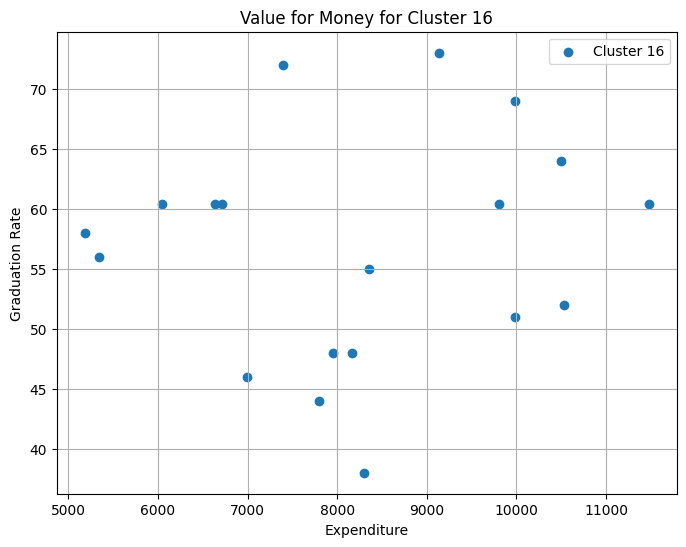

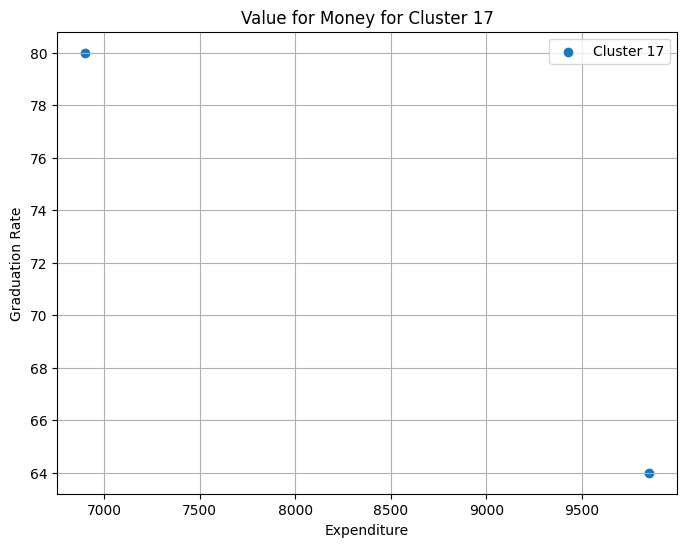

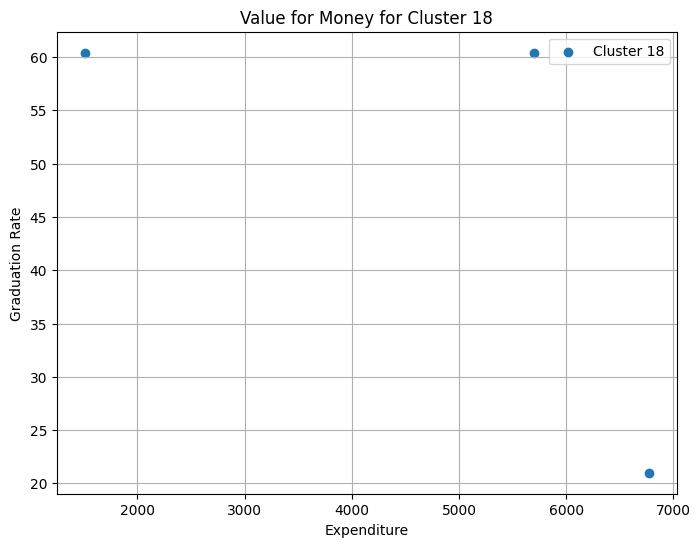

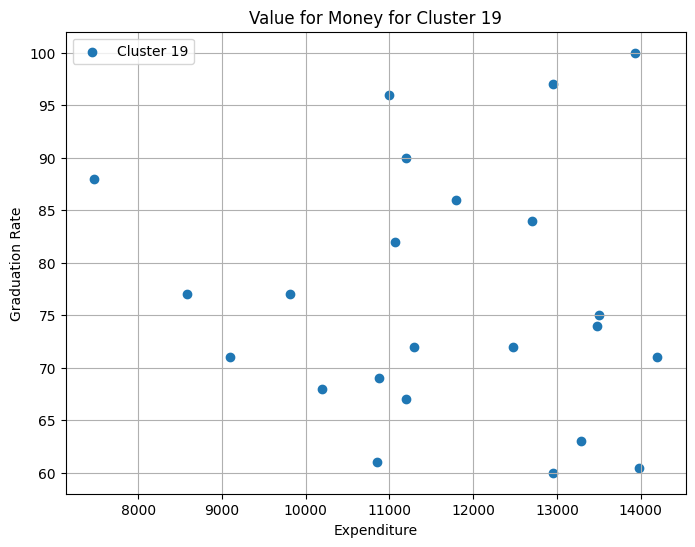

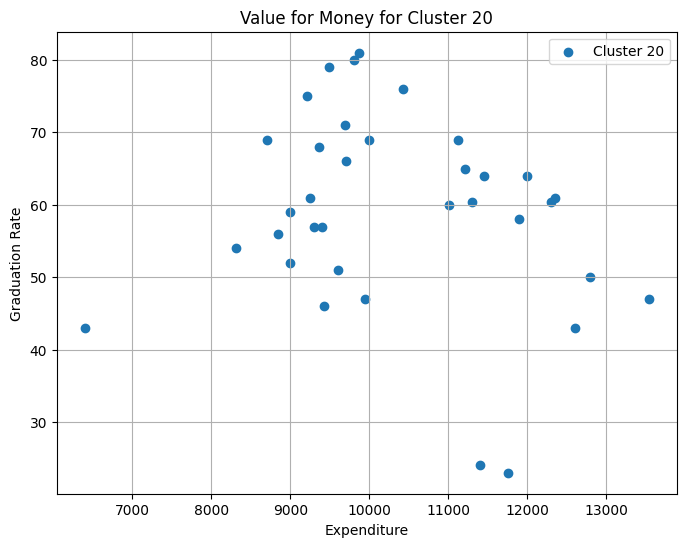

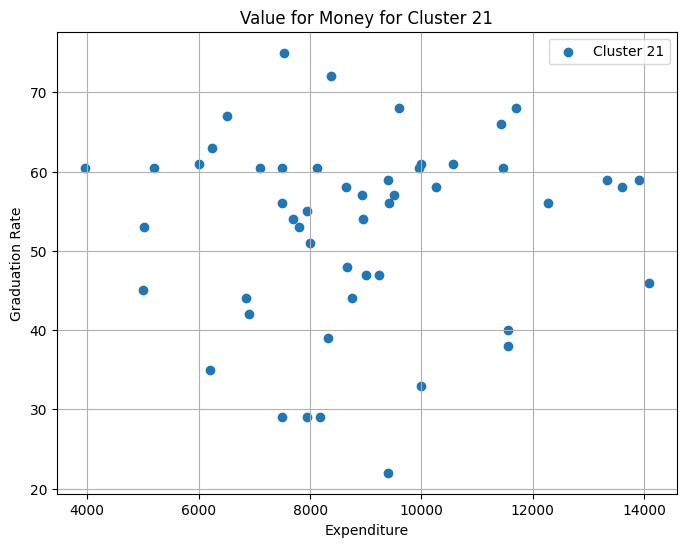

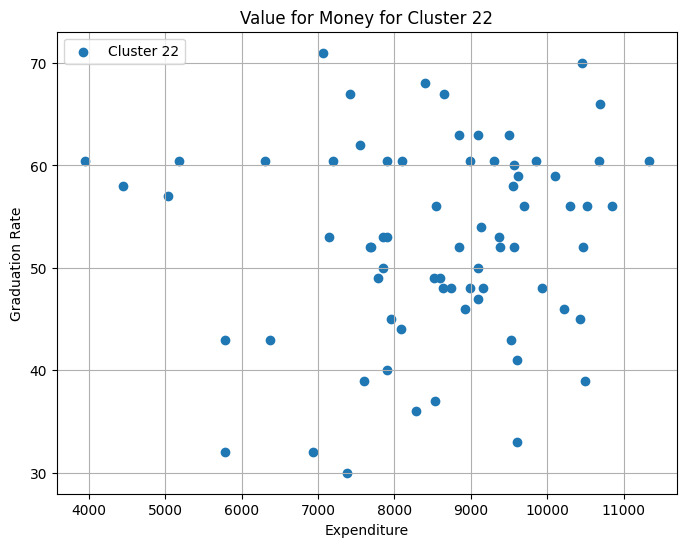

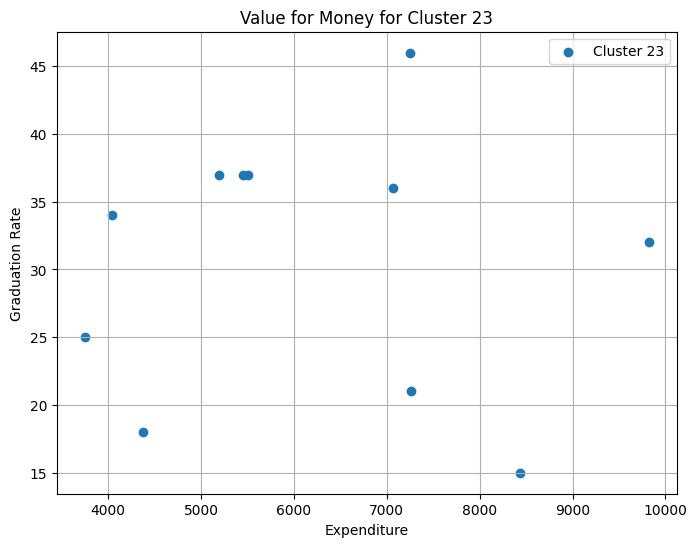

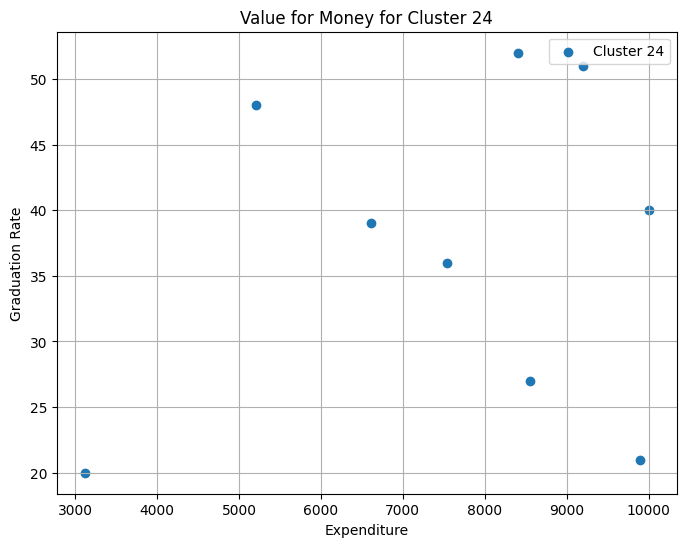

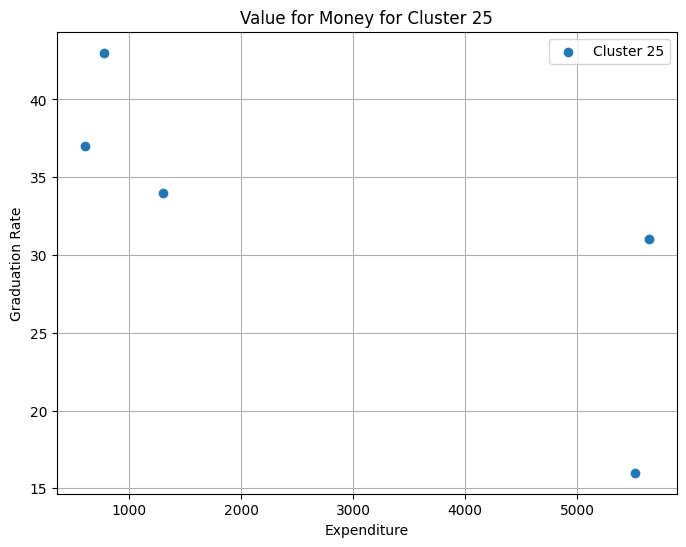

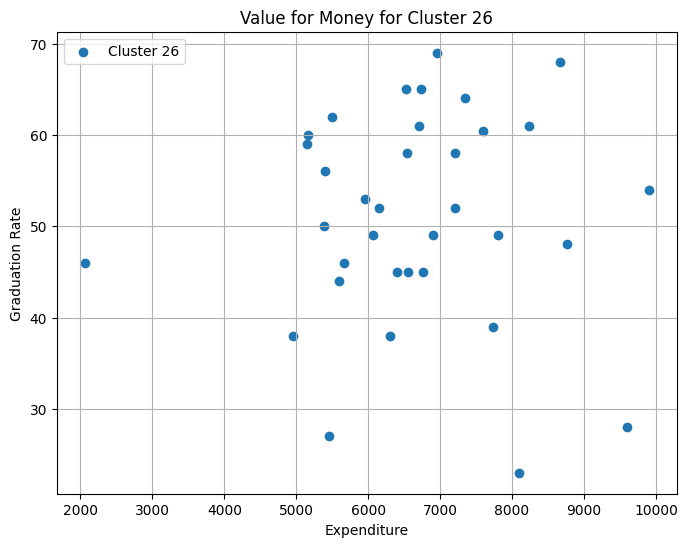

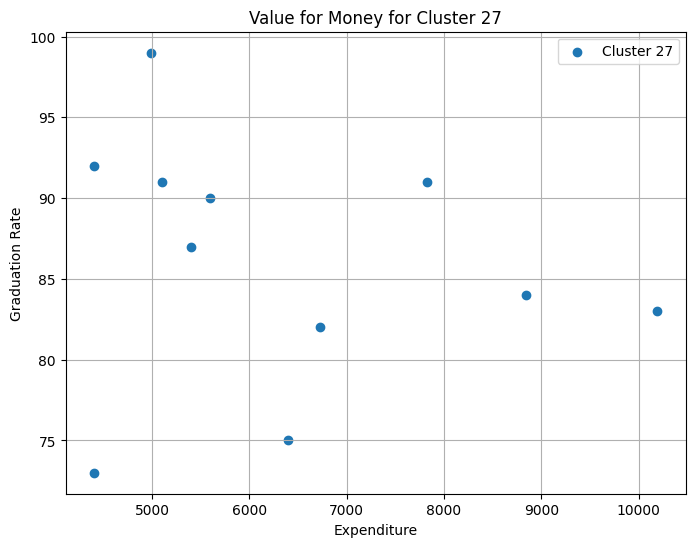

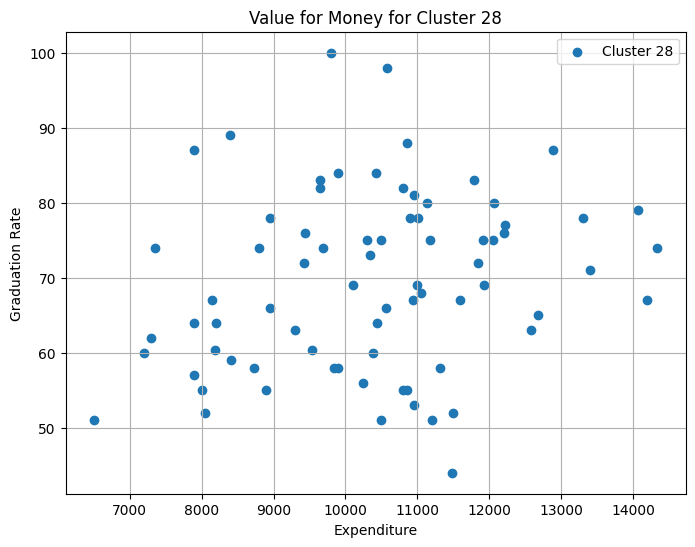

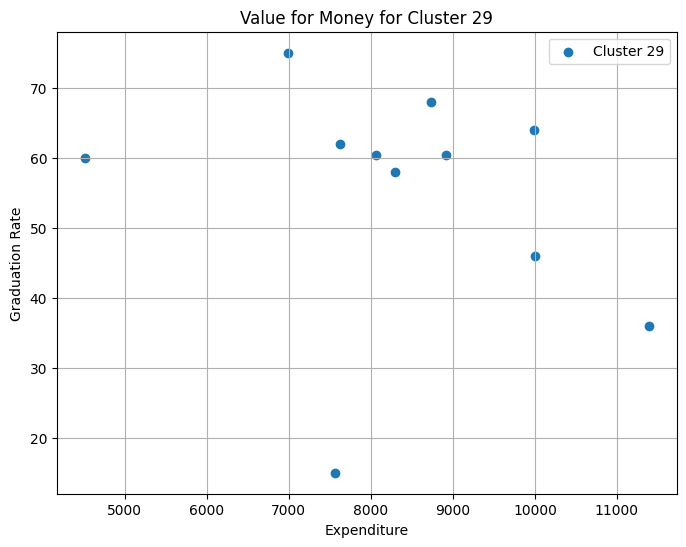

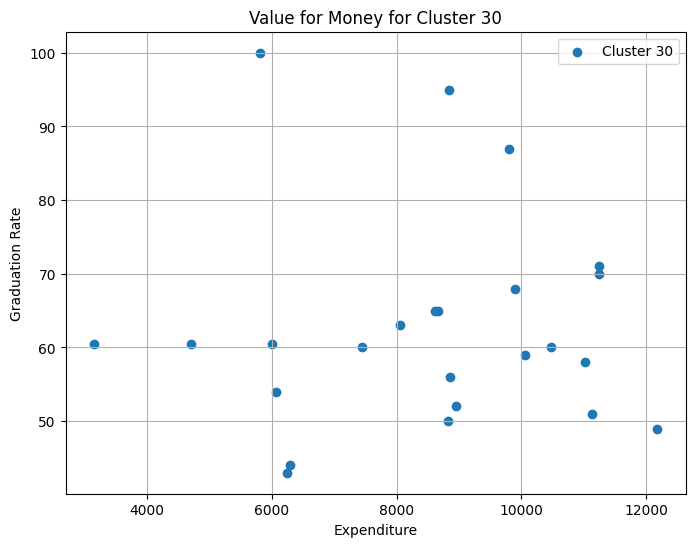

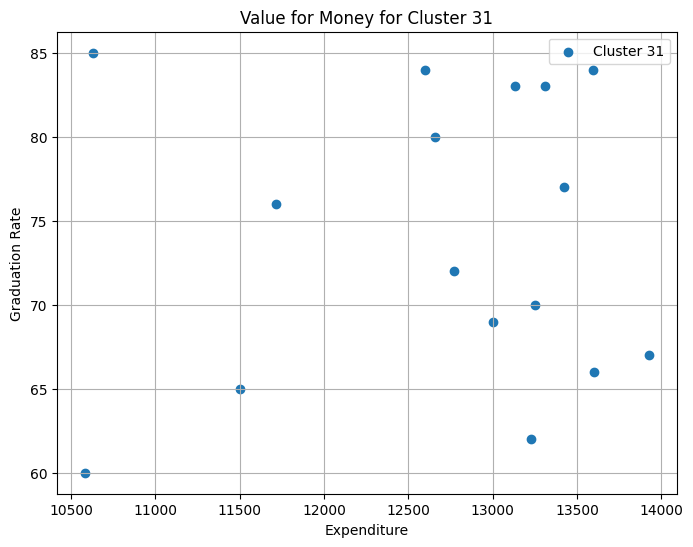

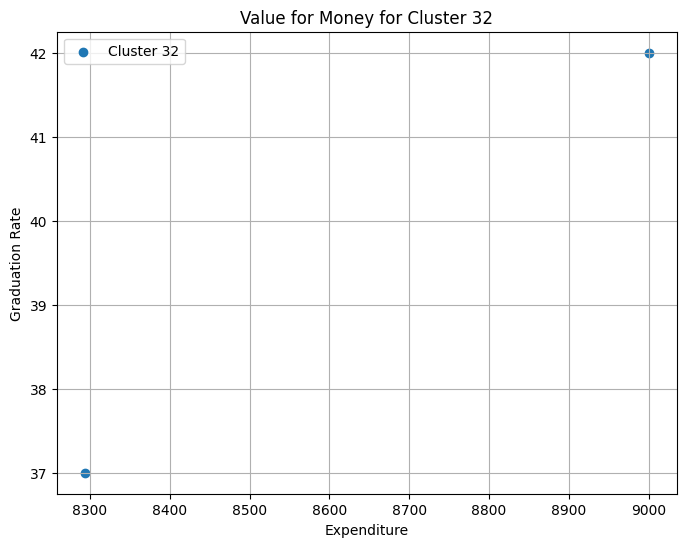

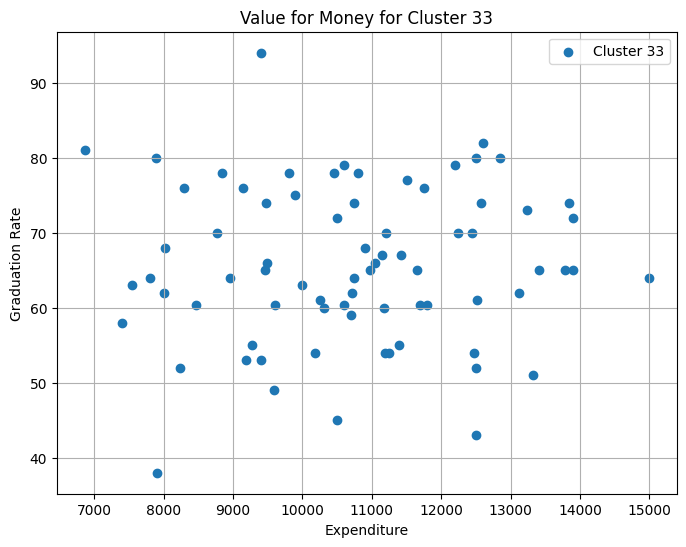

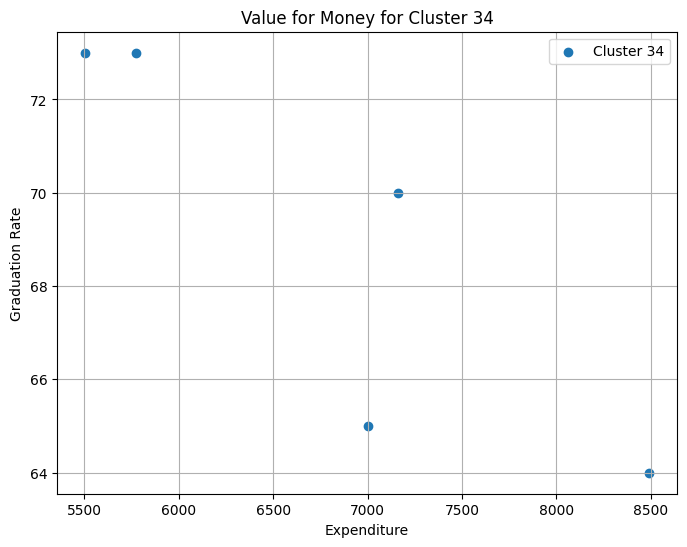

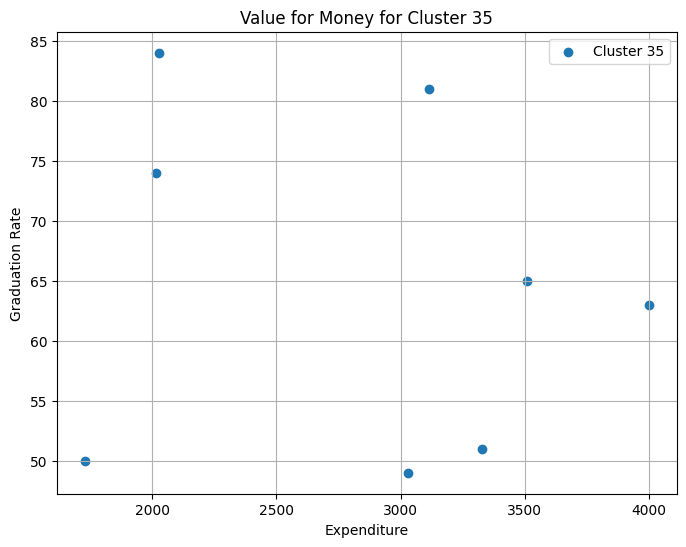

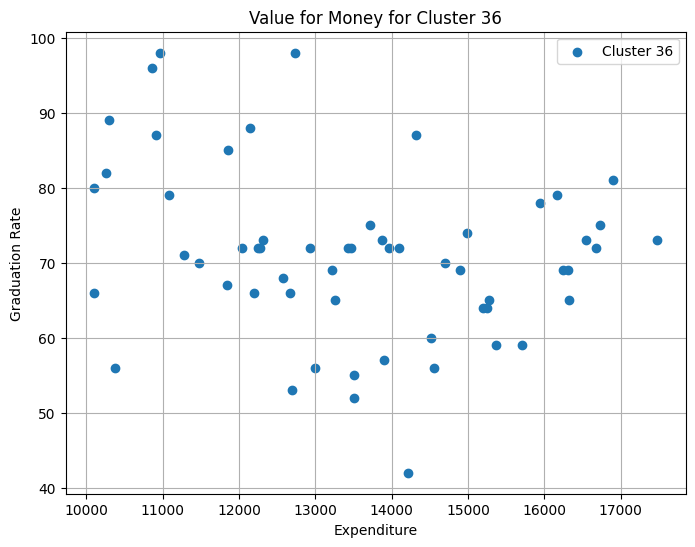

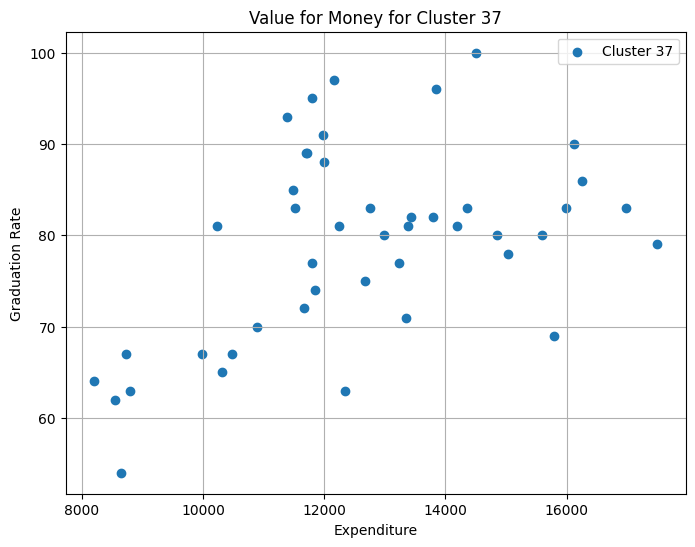

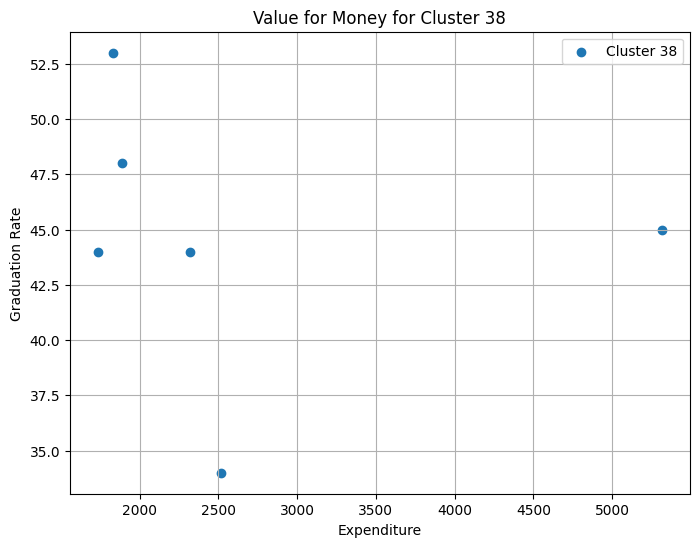

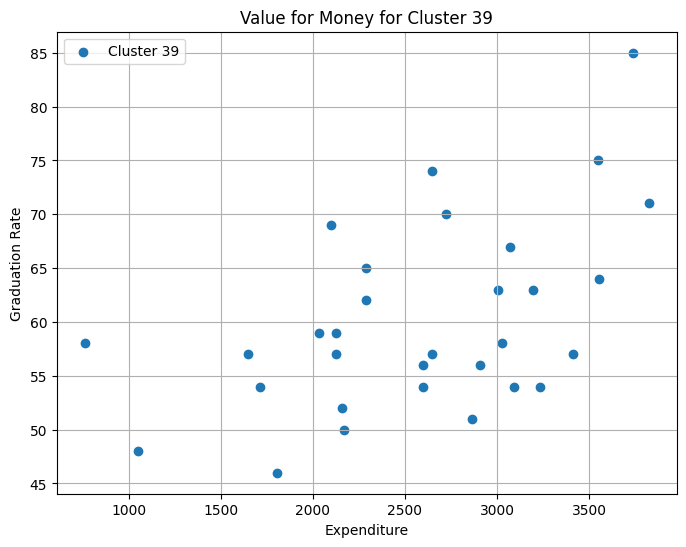

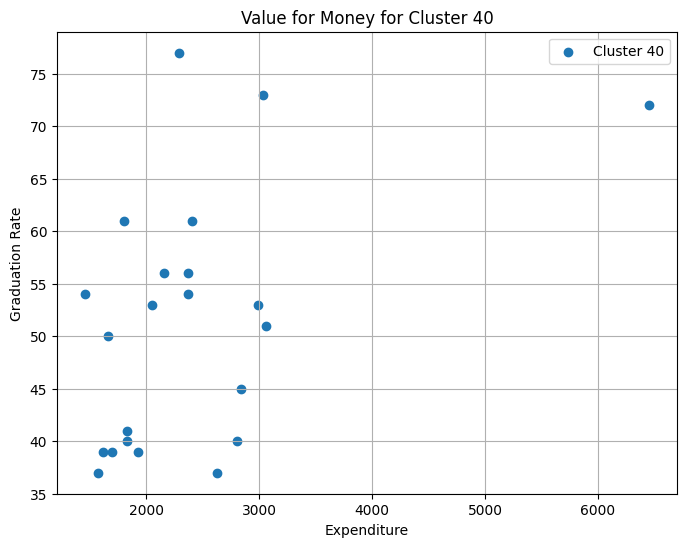

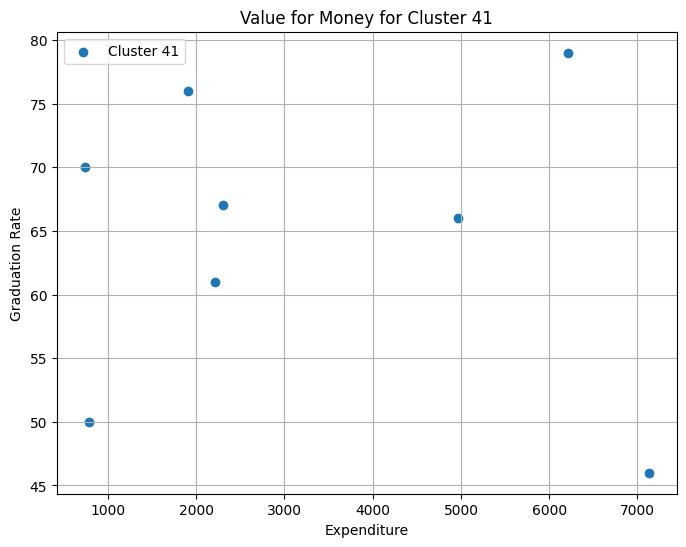

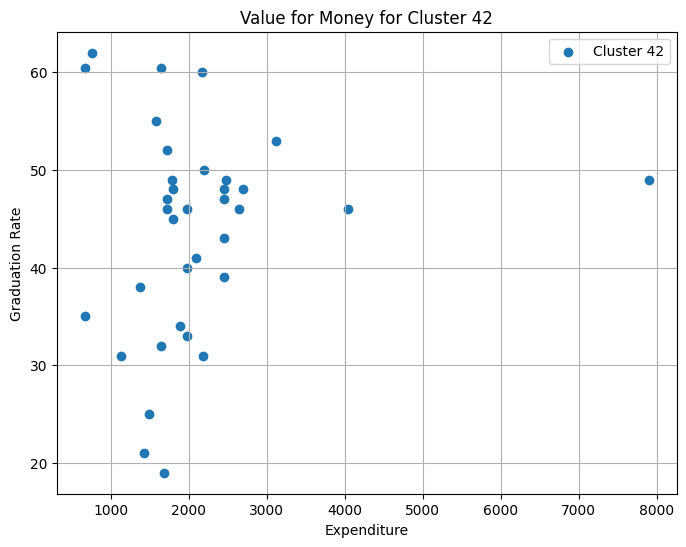

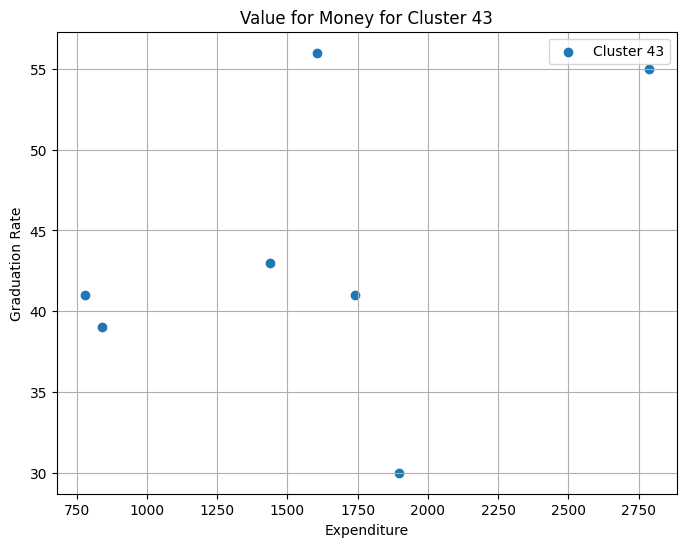

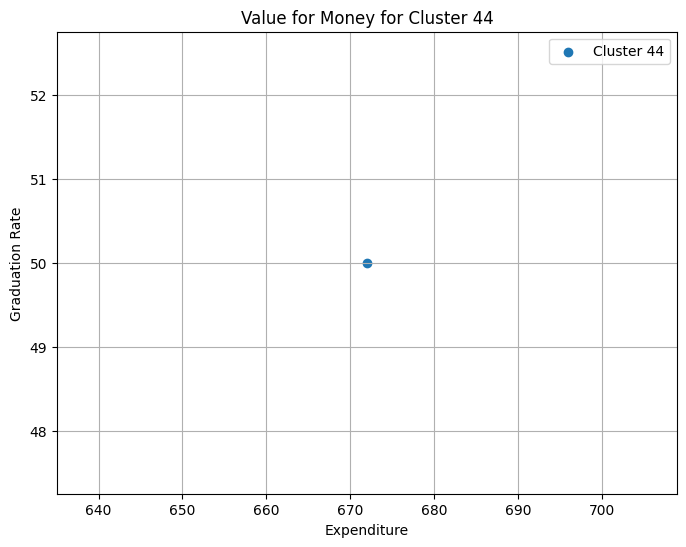

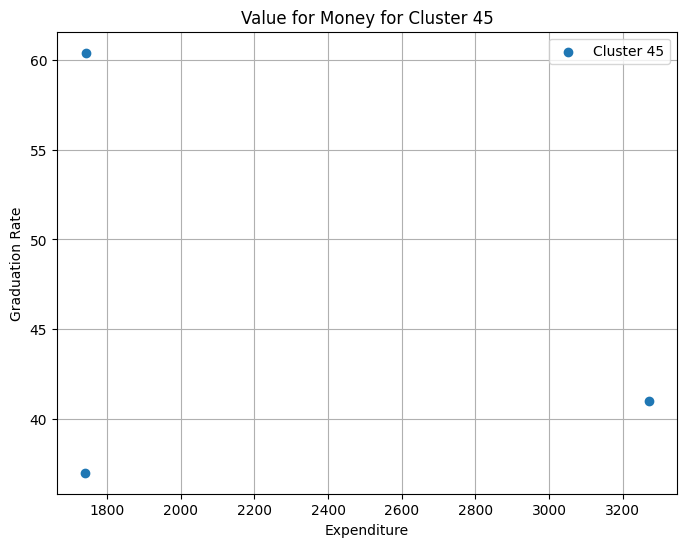

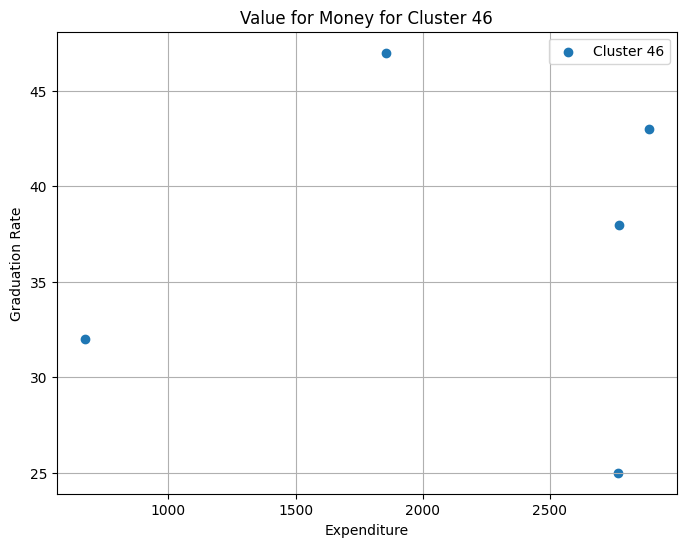

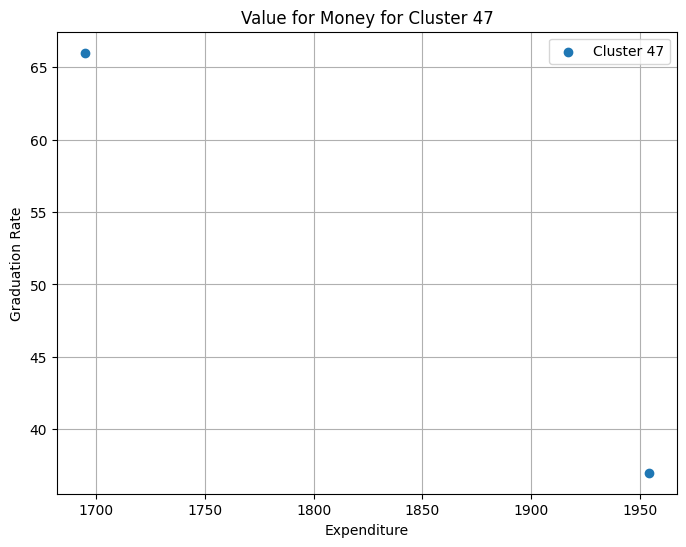

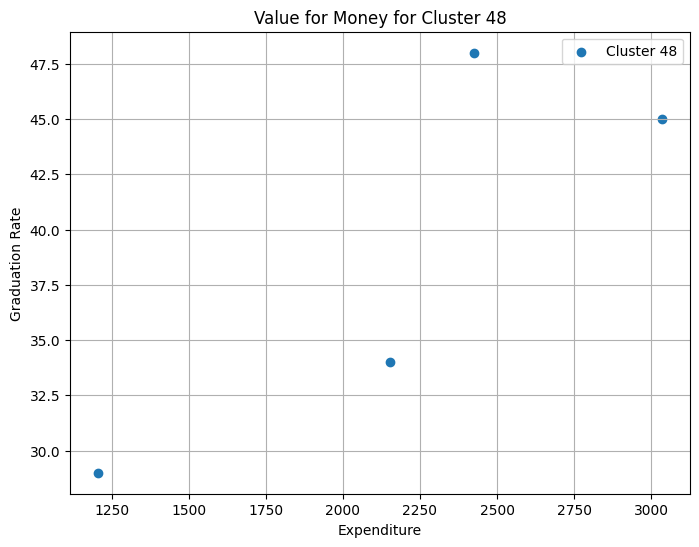

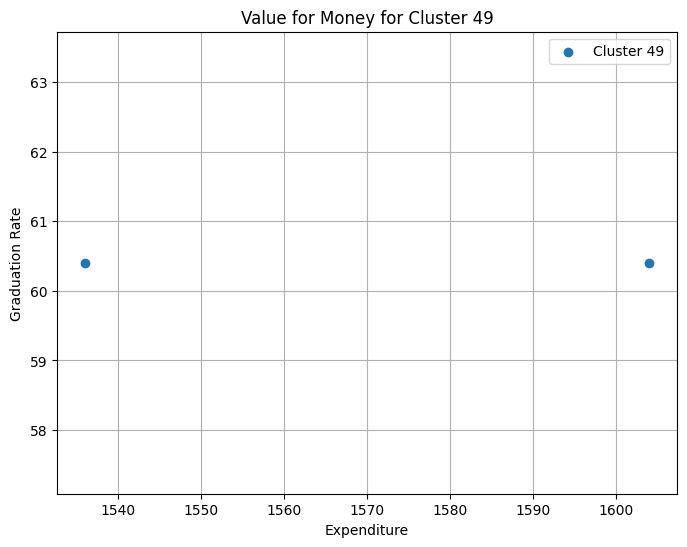

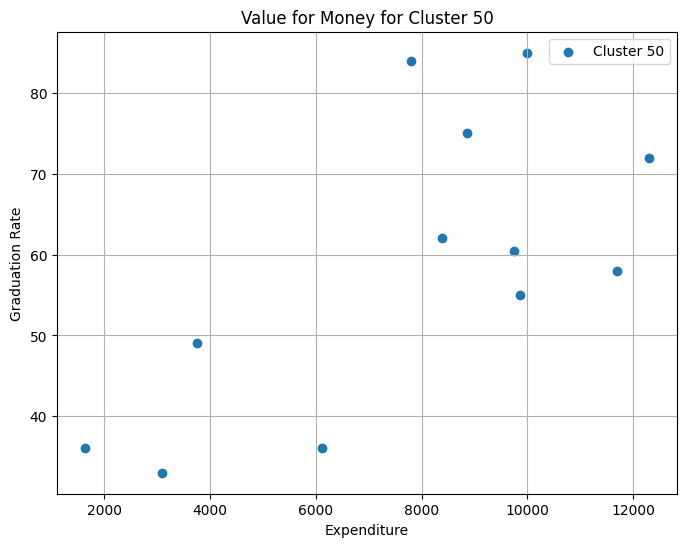

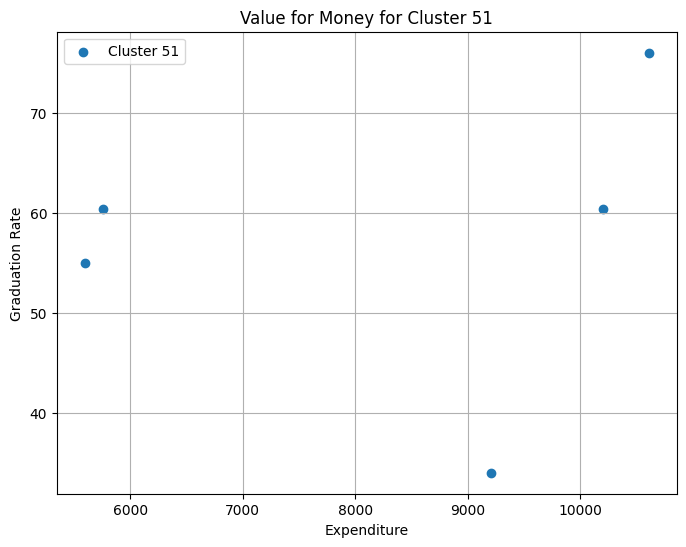

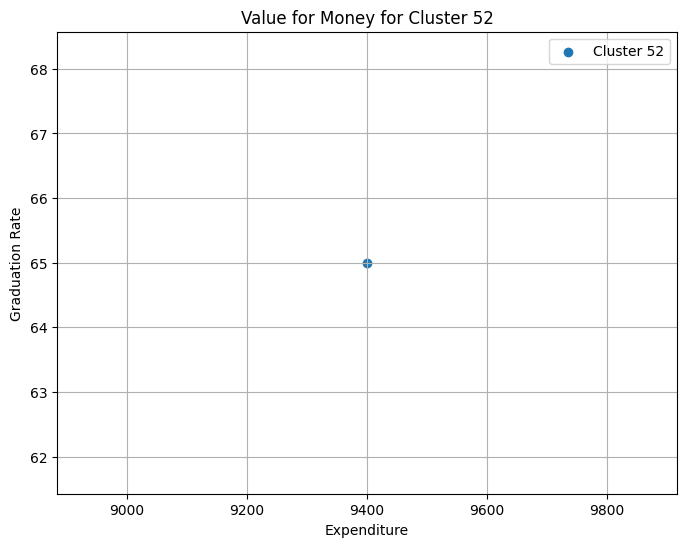

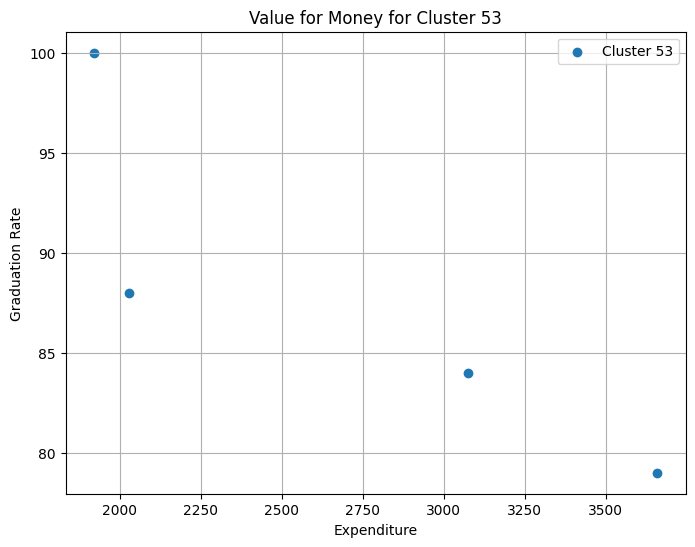

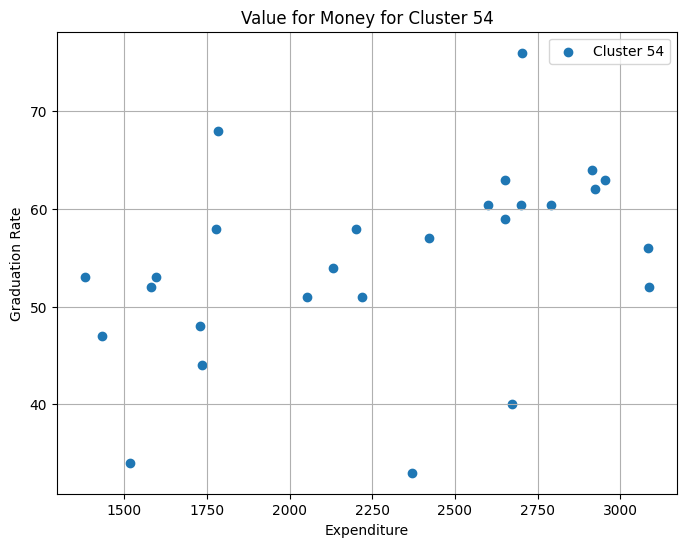

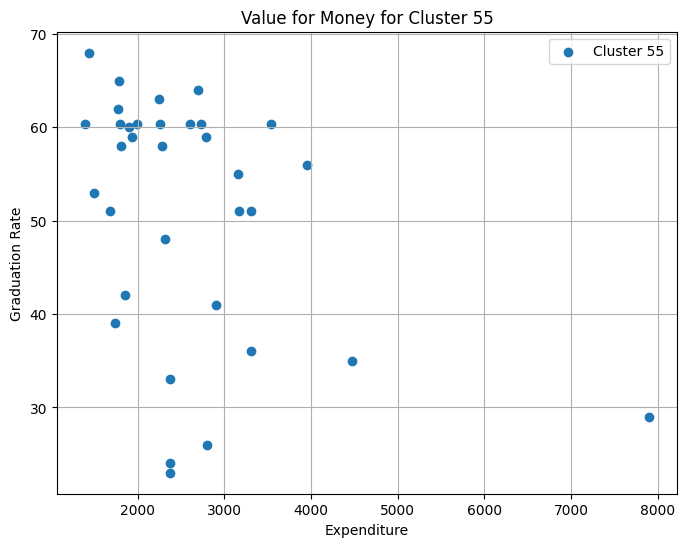

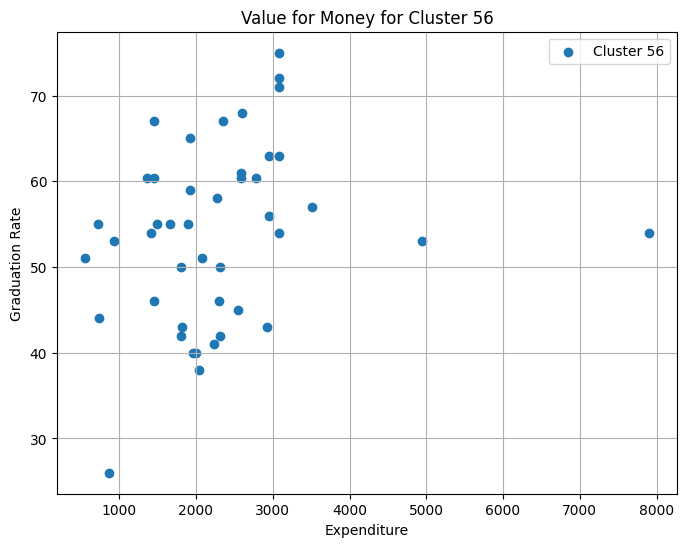

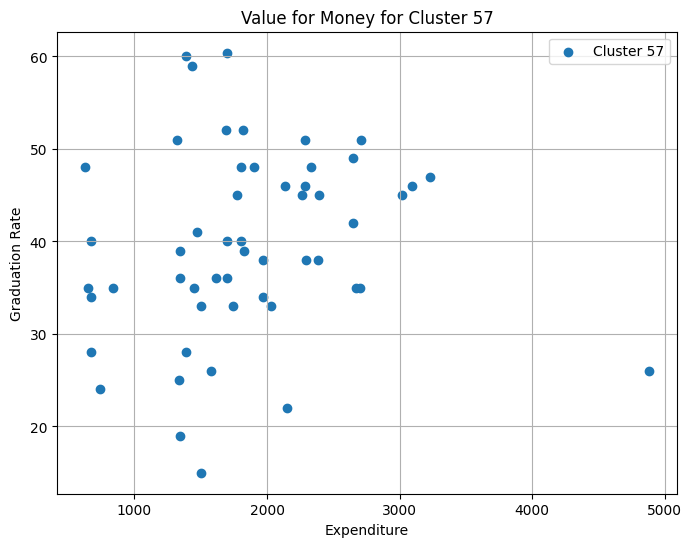

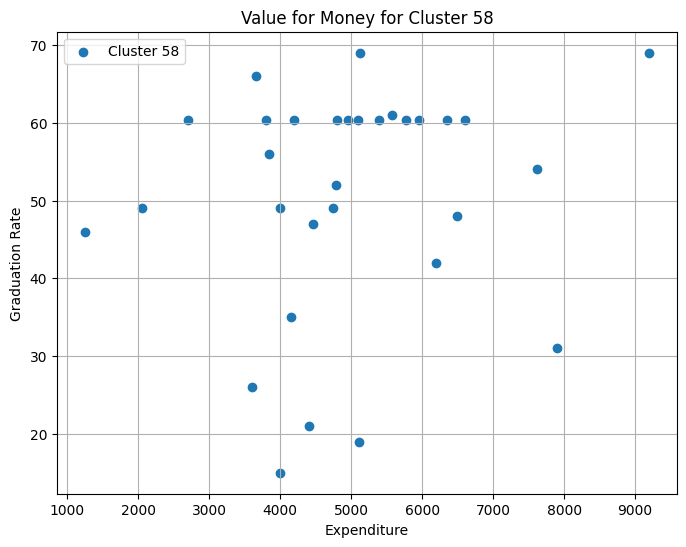

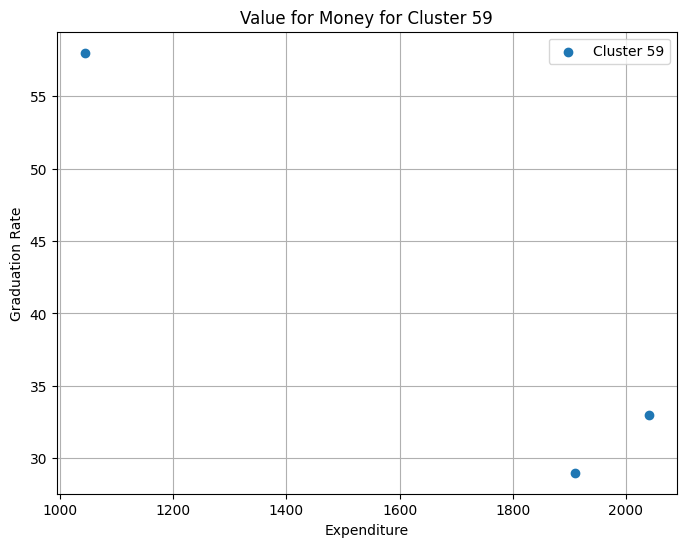

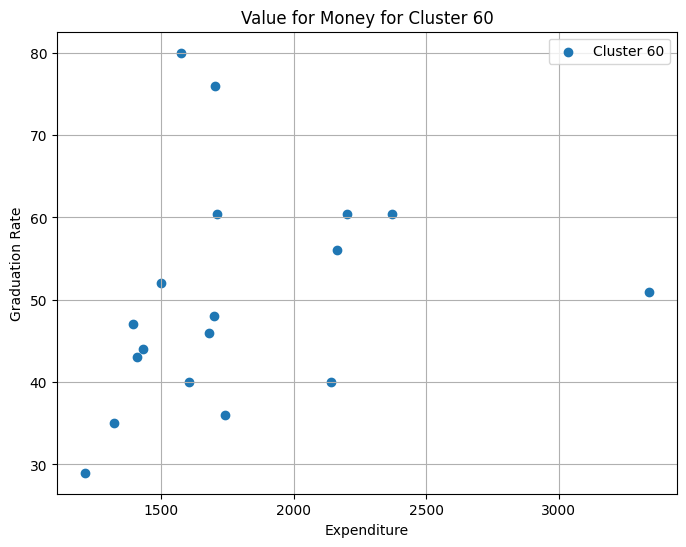

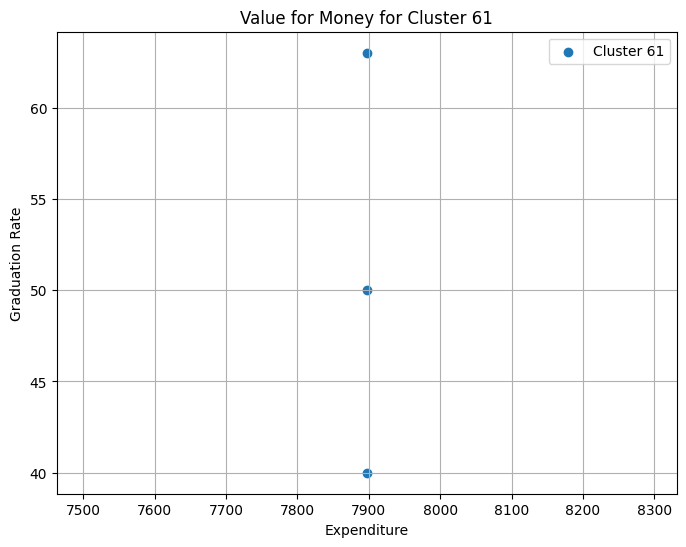

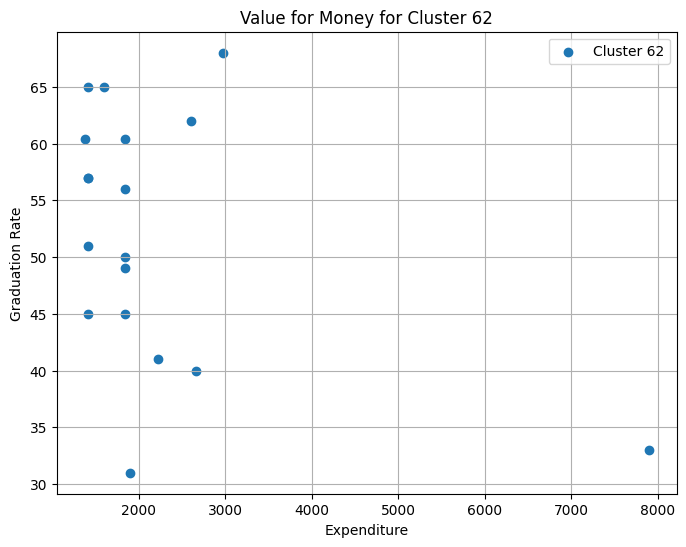

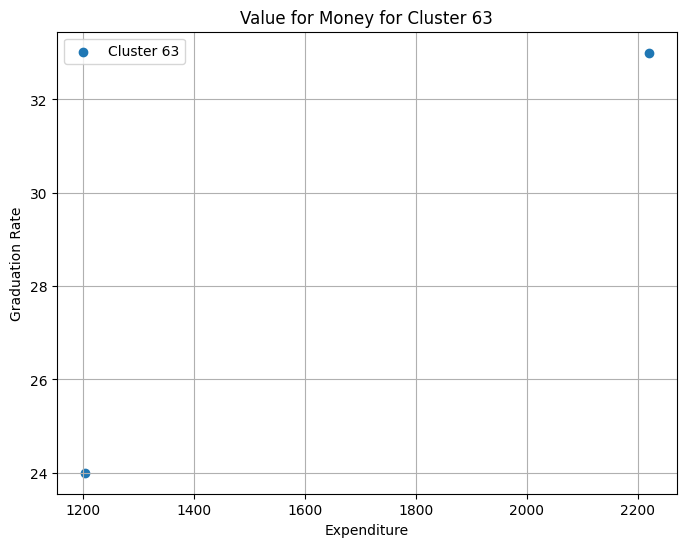

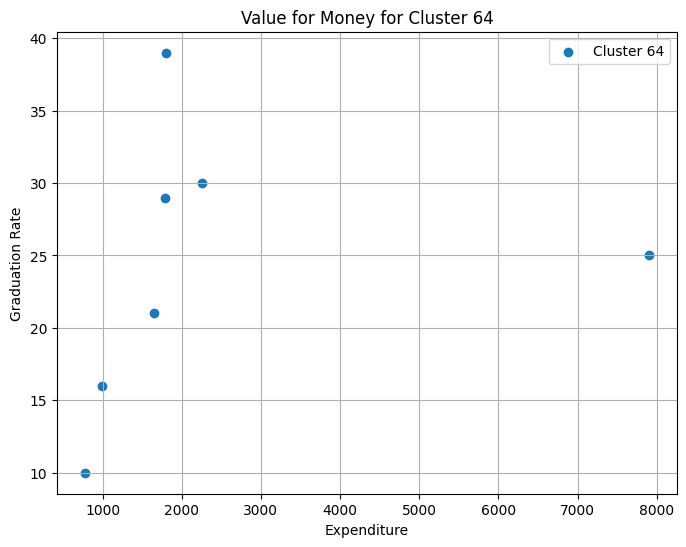

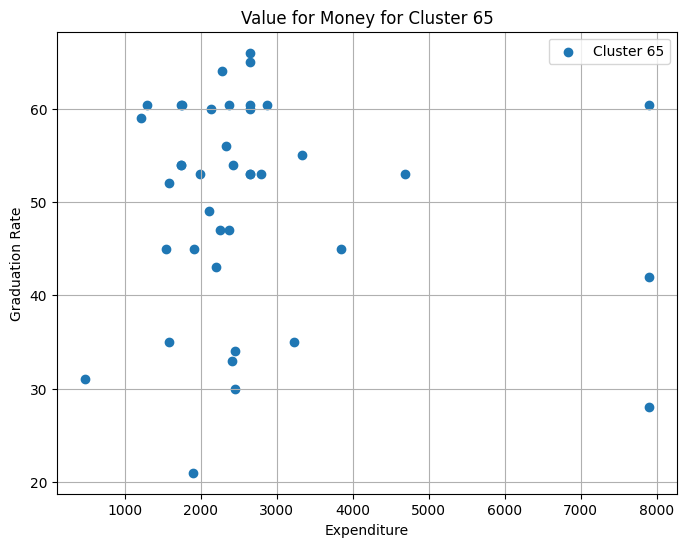

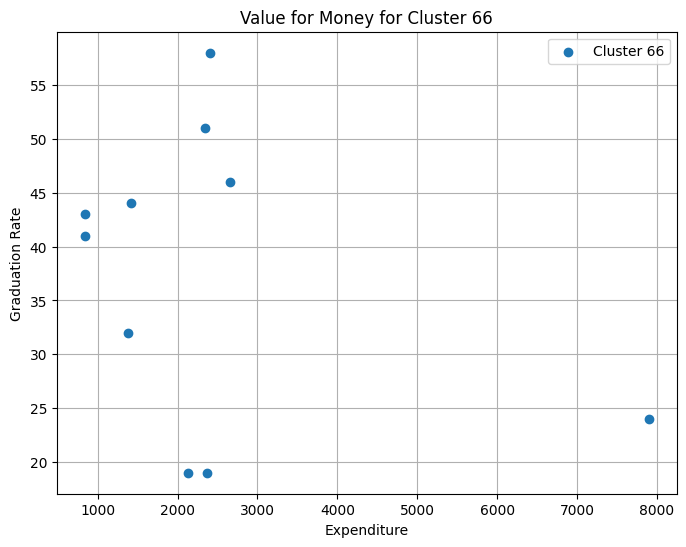

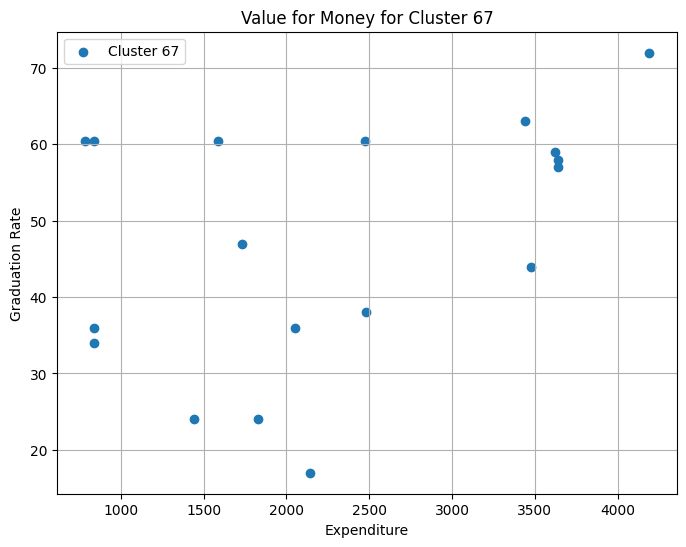

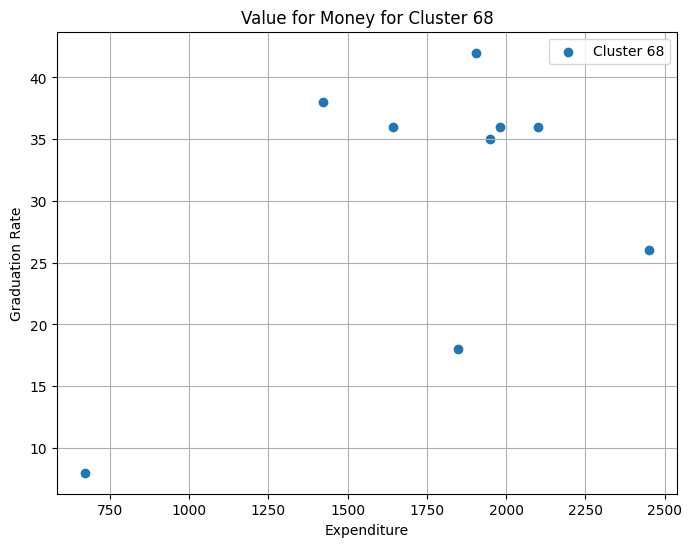

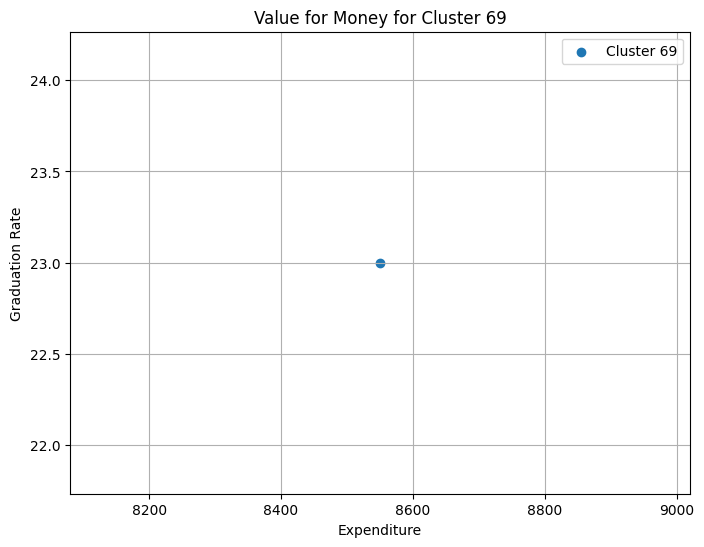

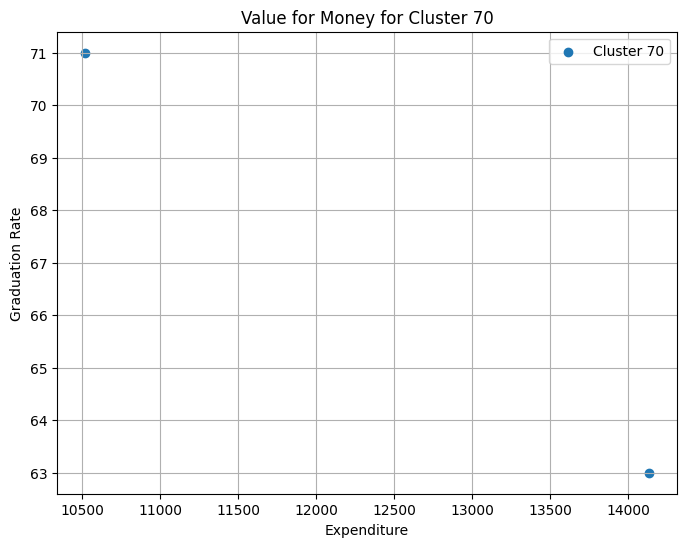

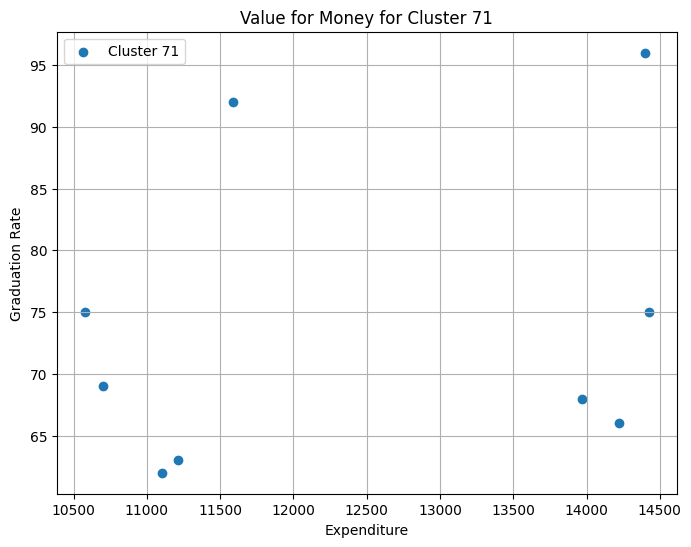

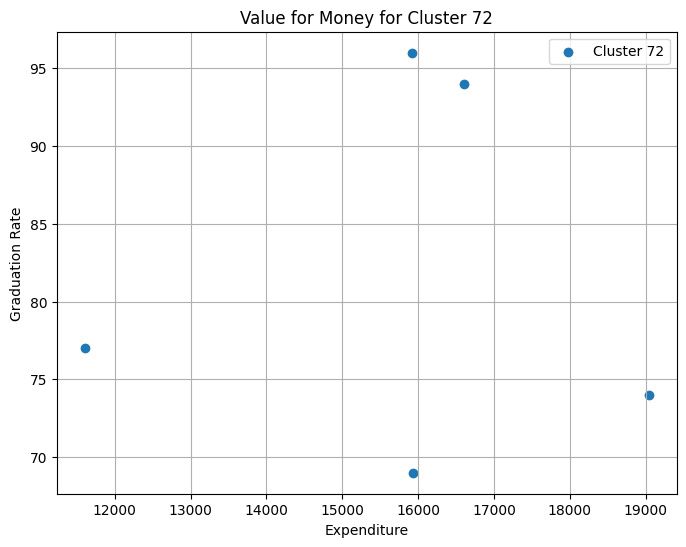

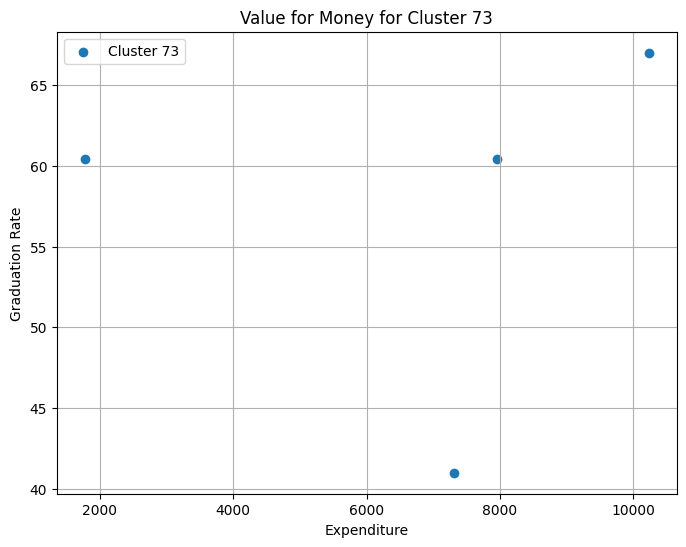

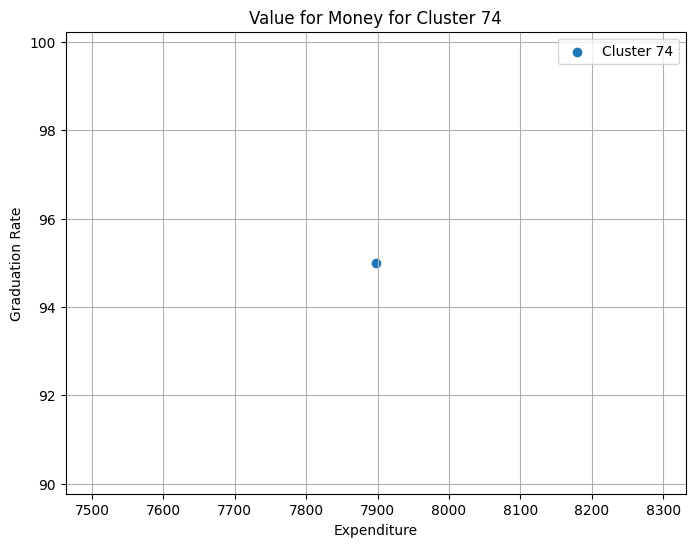

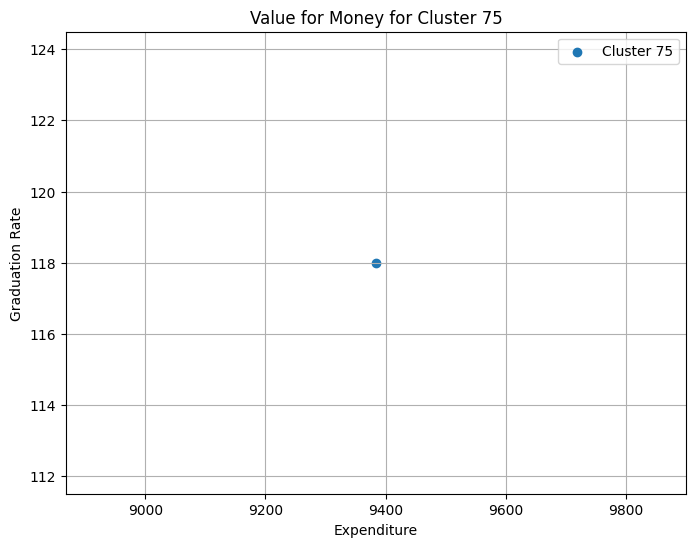

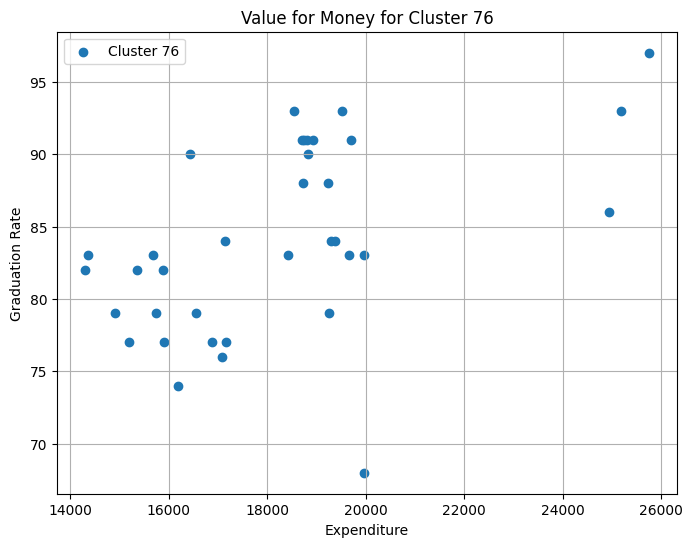

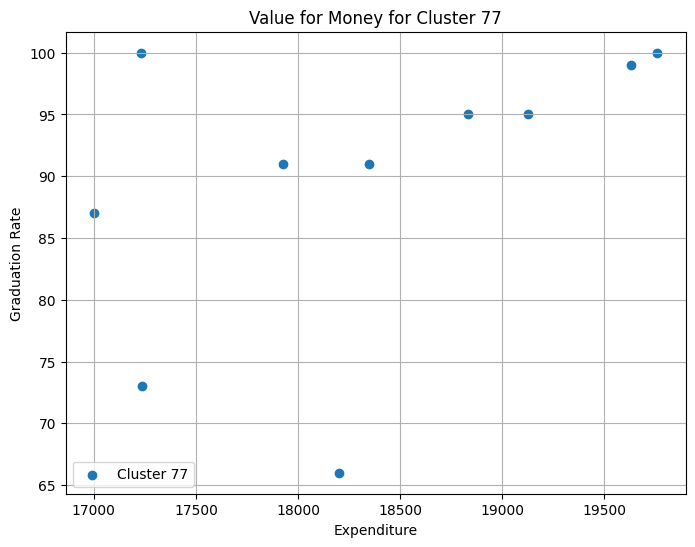

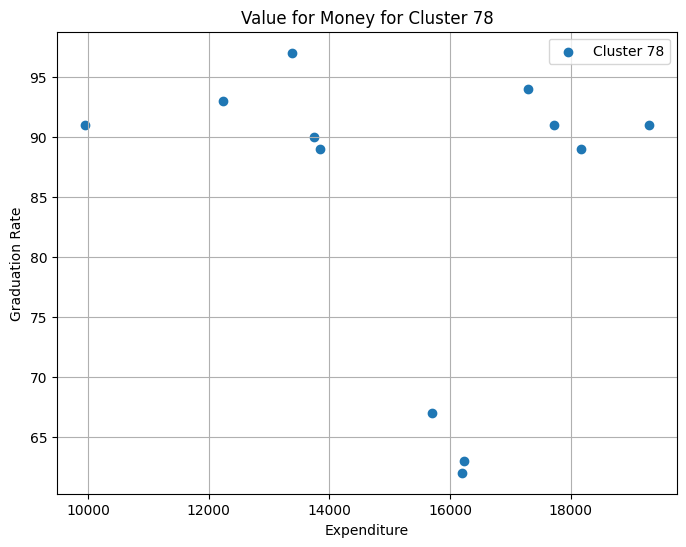

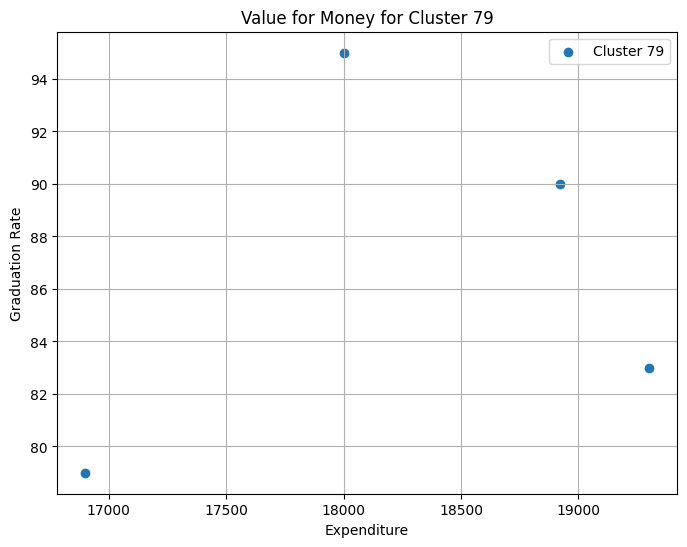

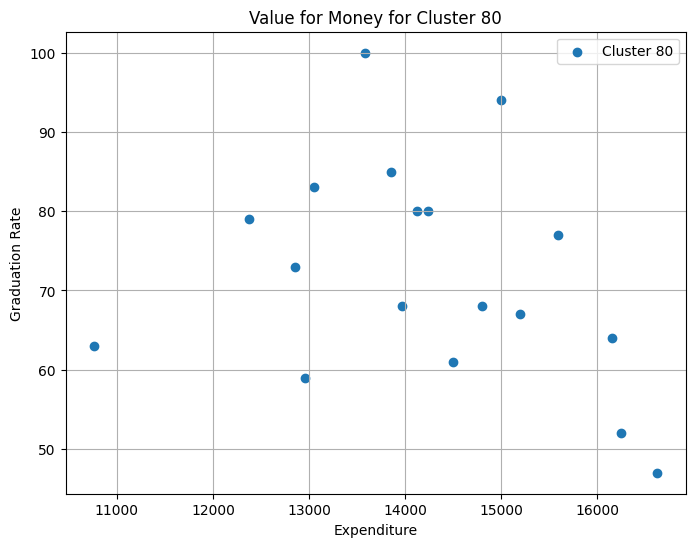

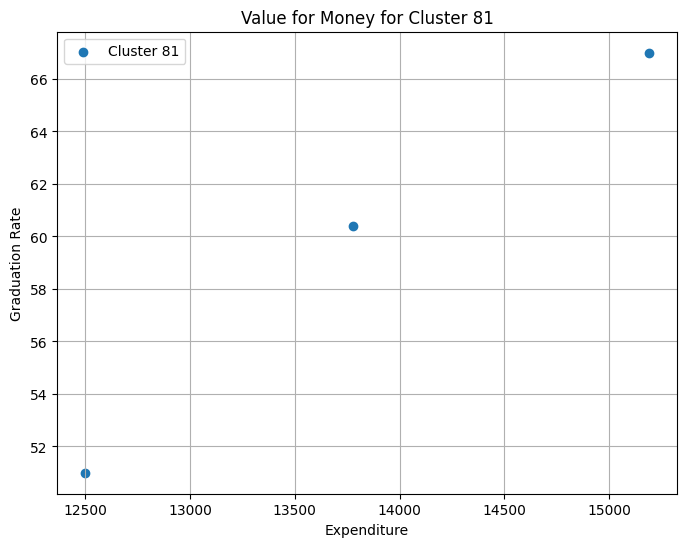

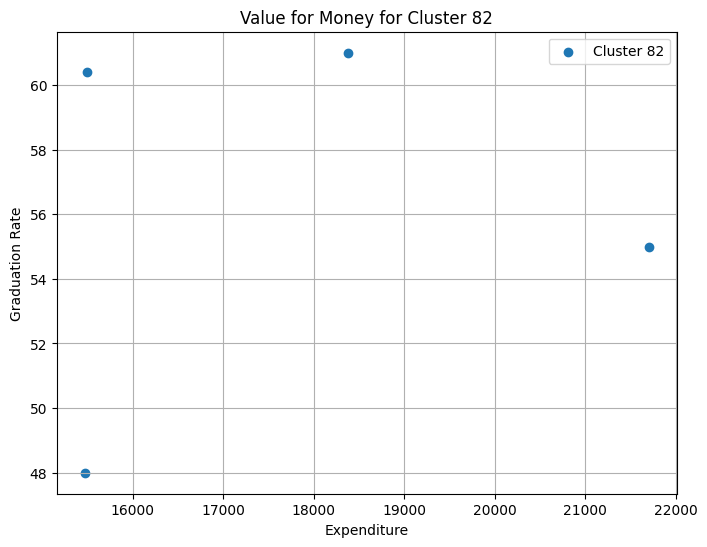

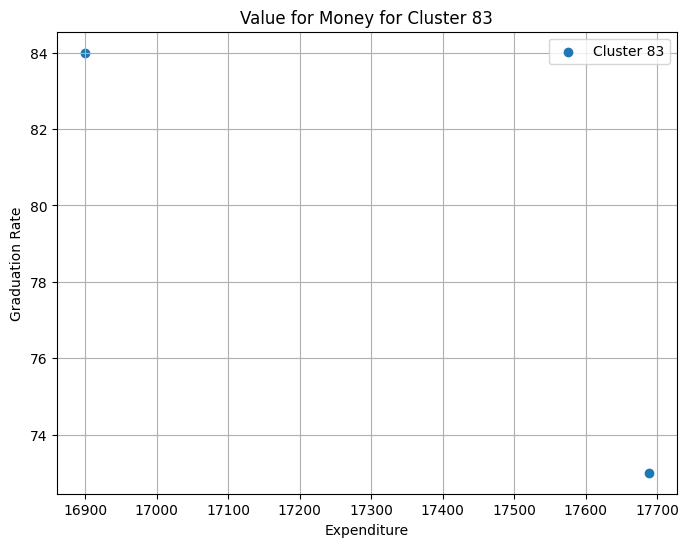

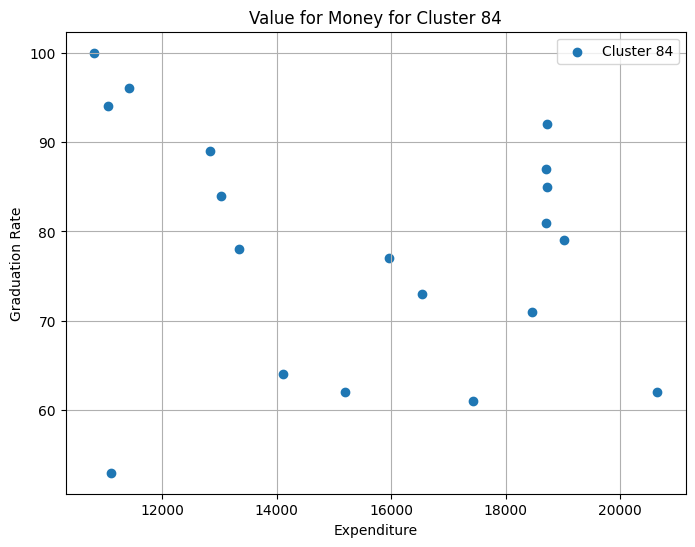

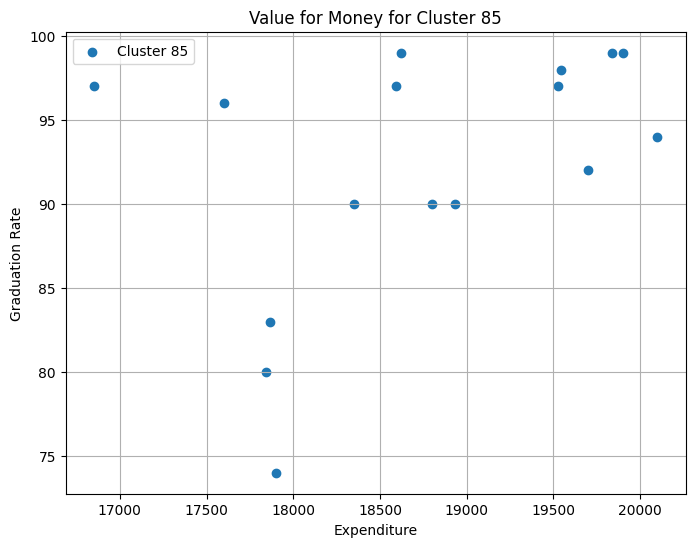

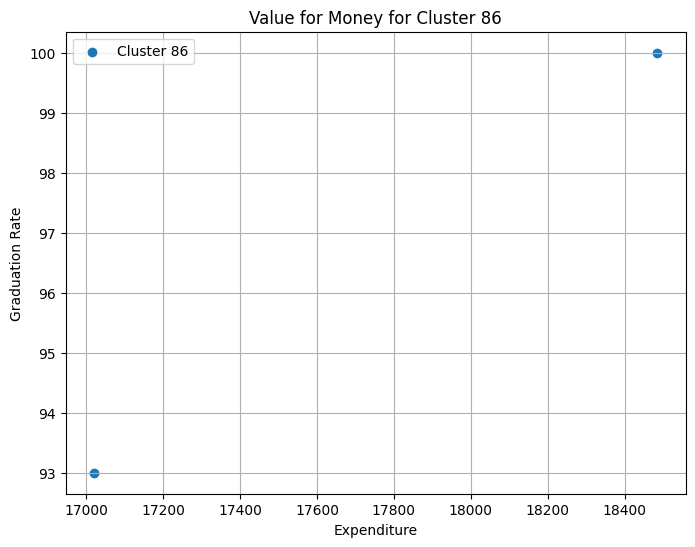

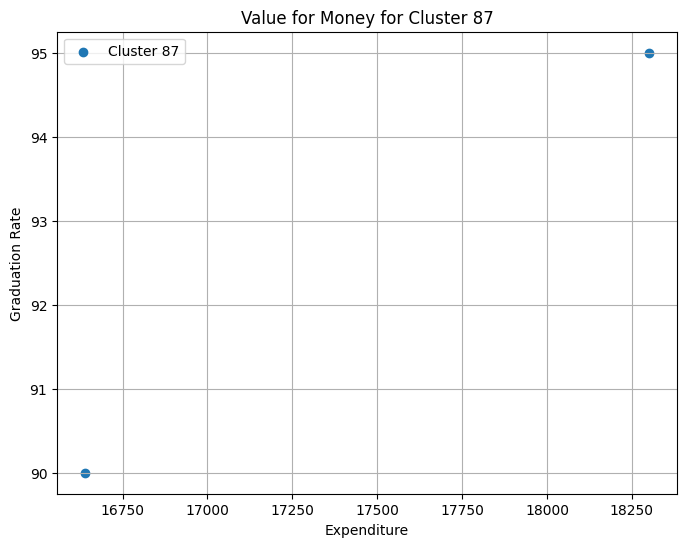

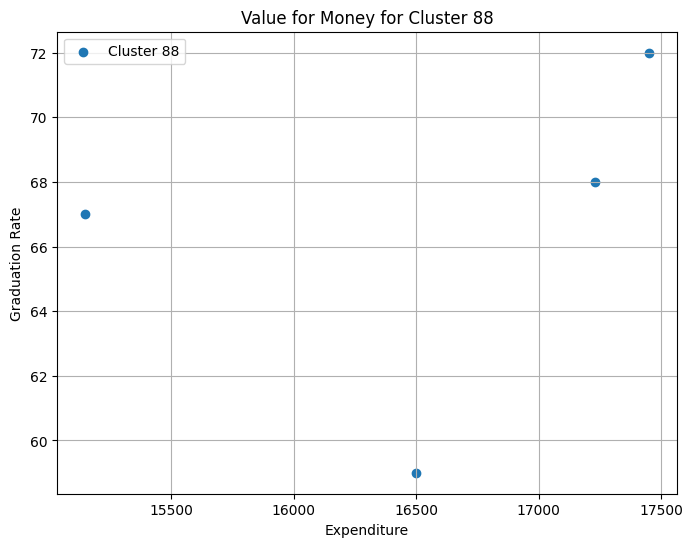

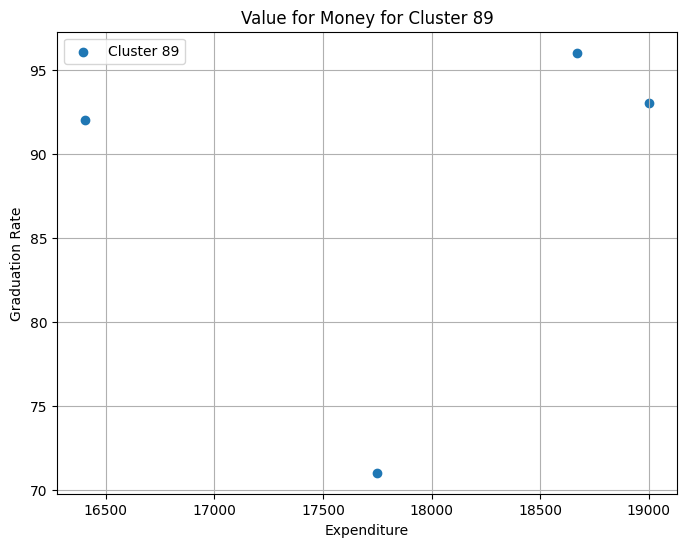

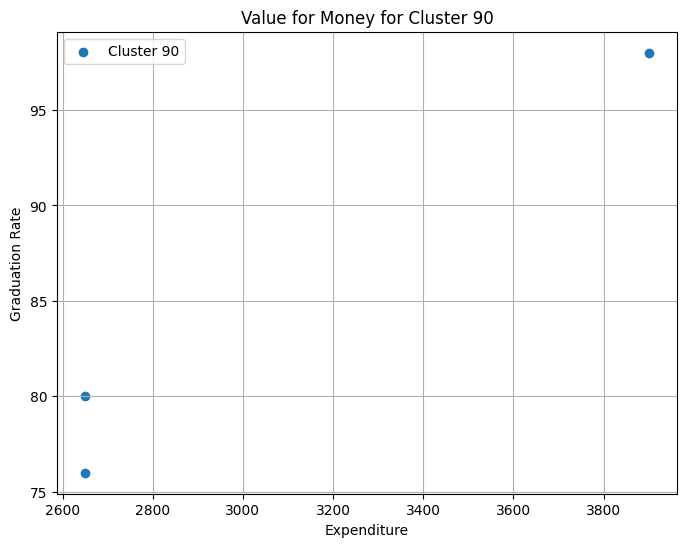

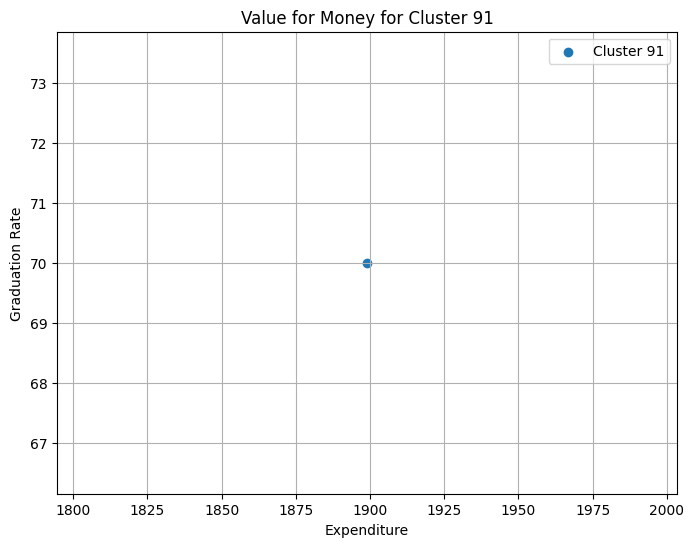

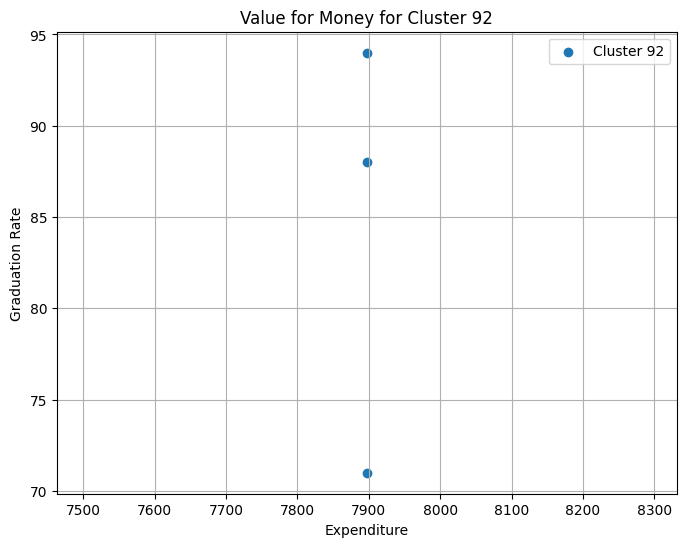

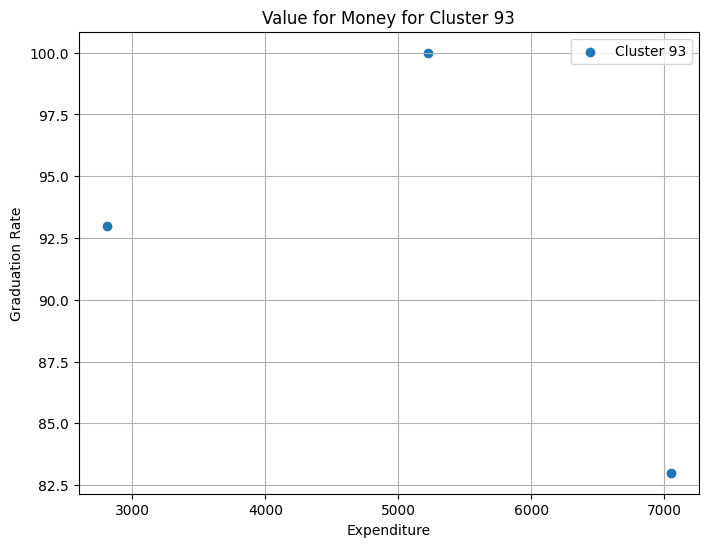

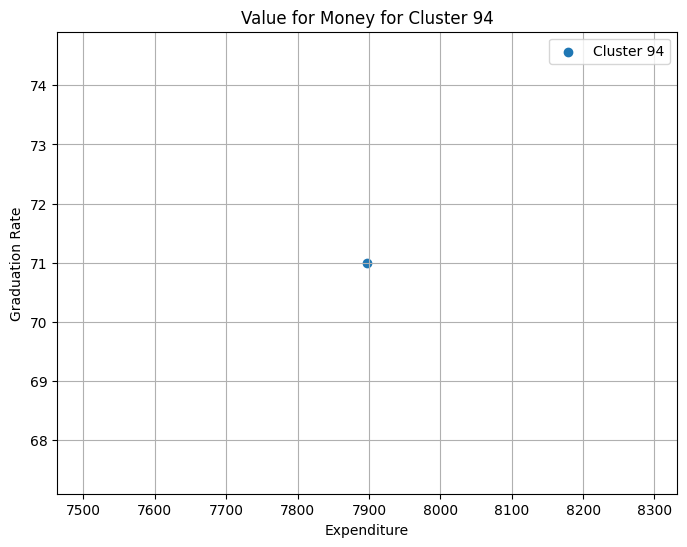

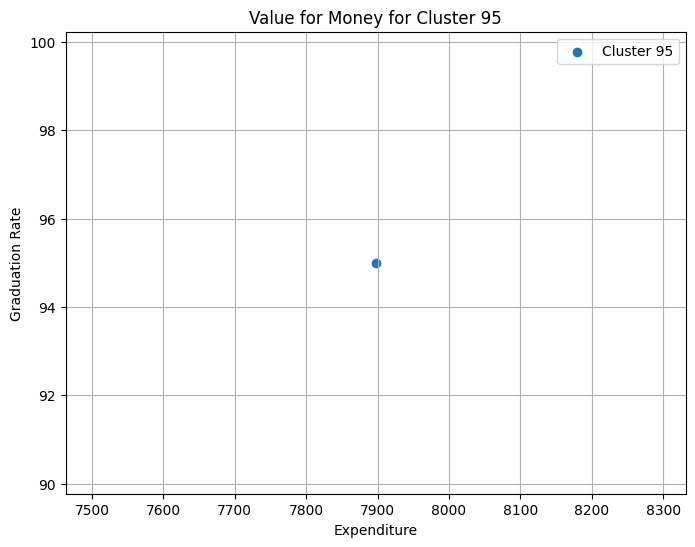

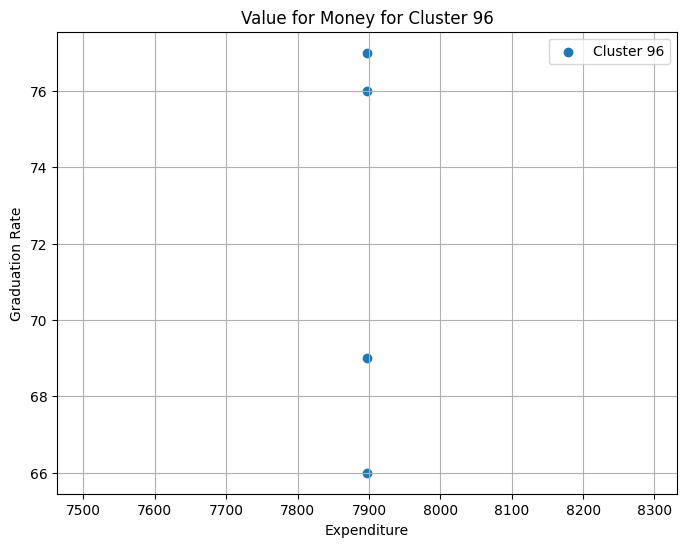

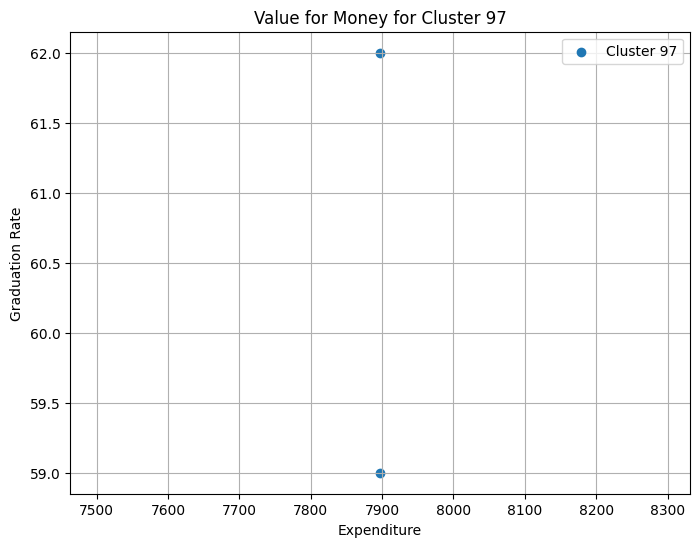

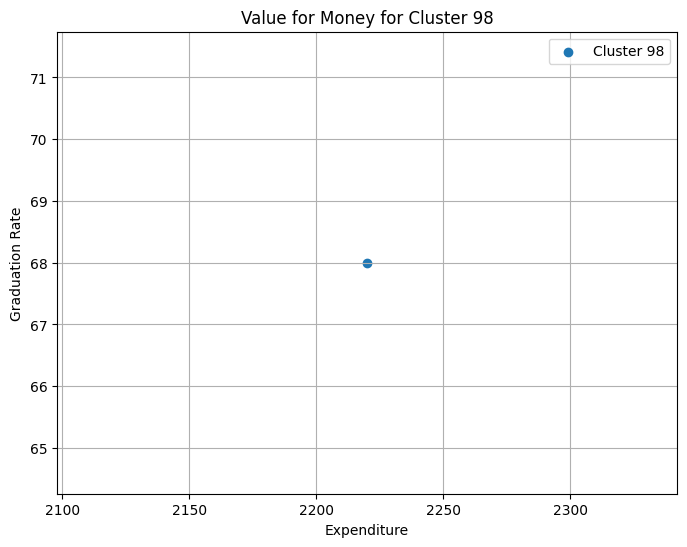

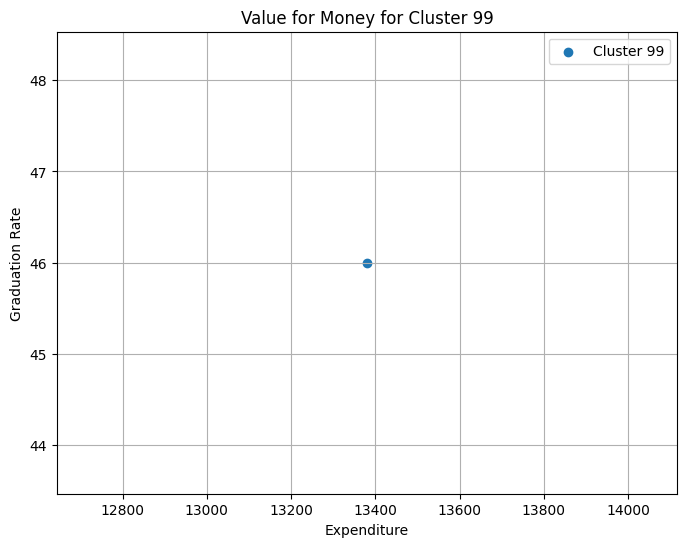

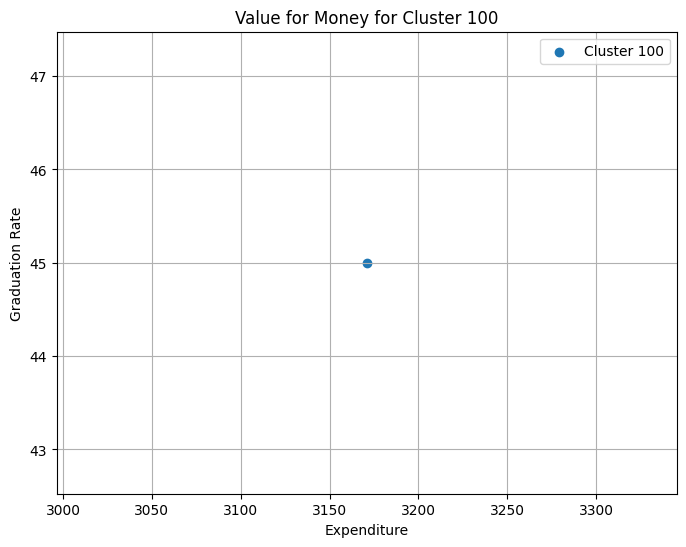

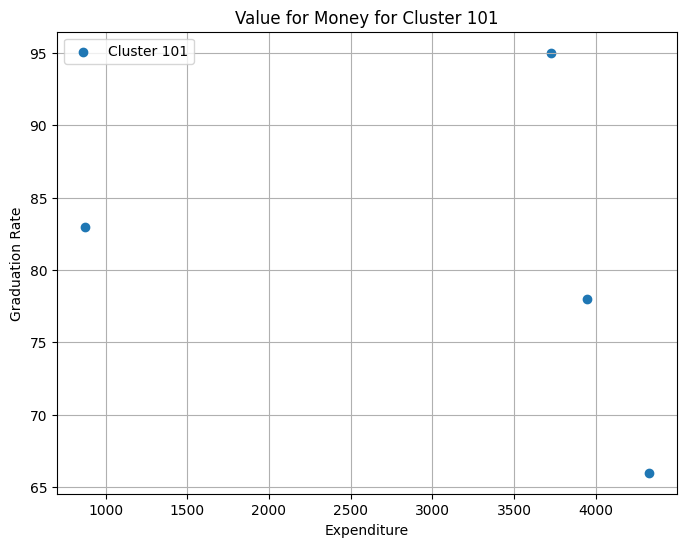

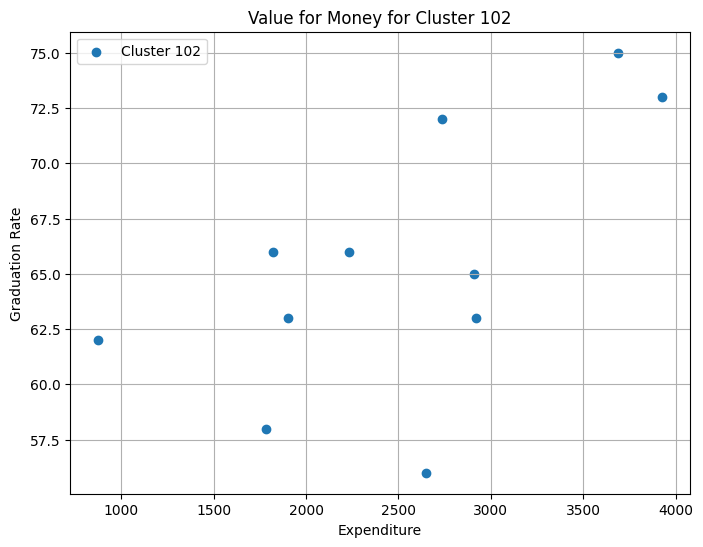

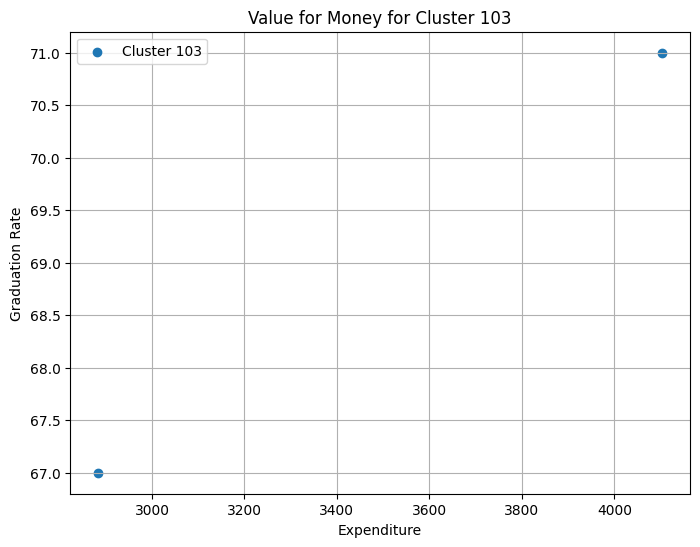

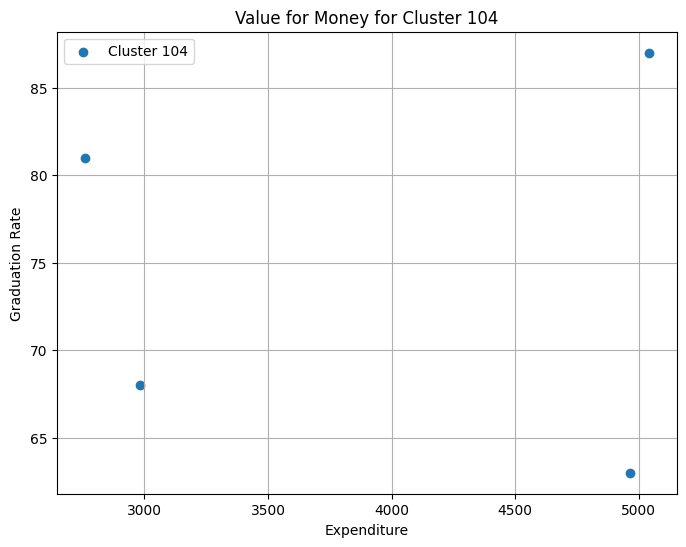

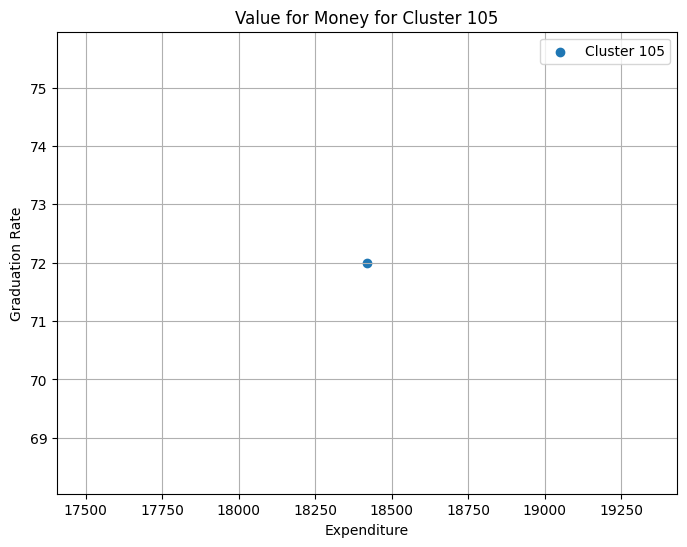

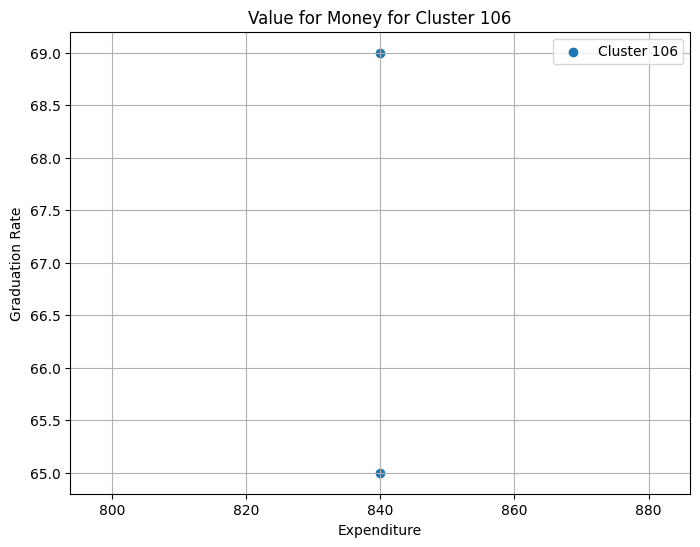

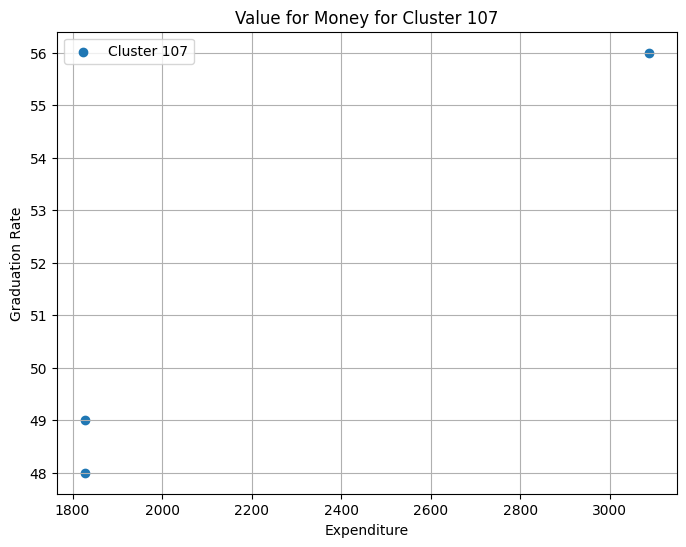

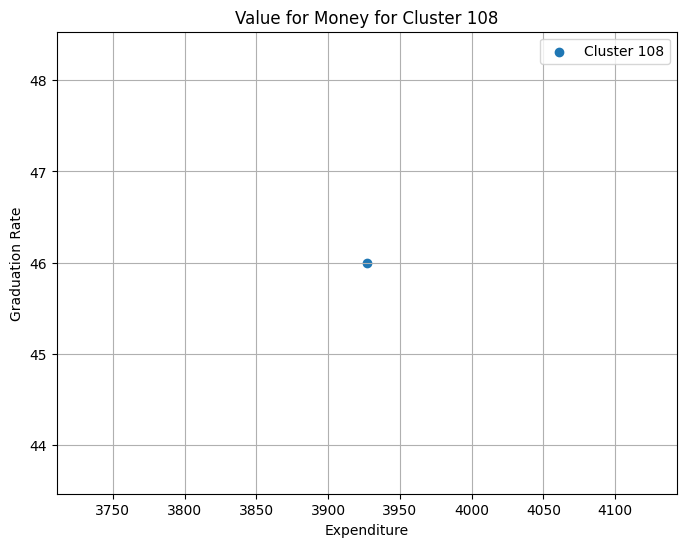

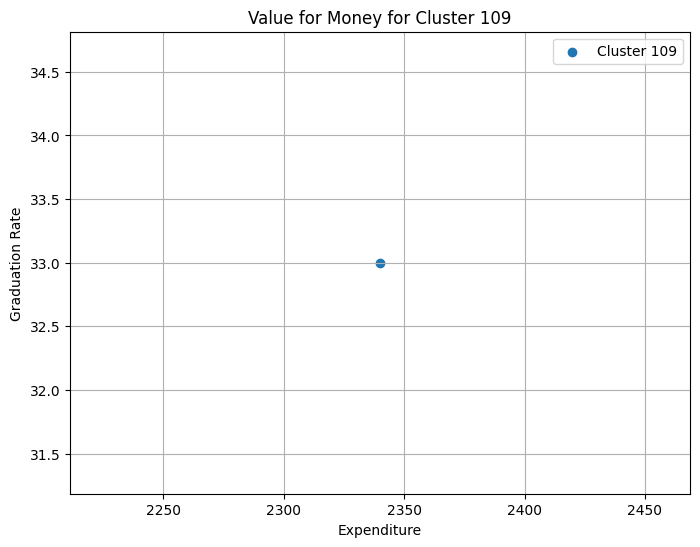

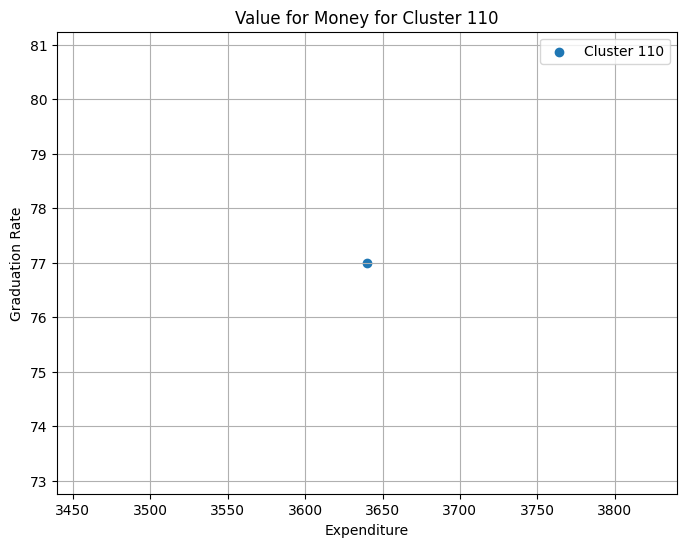

         # appl. accepted  Graduation rate  % fac. w/PHD
Cluster                                                 
1                   683.0        60.405316     47.000000
2                   998.0        35.000000     33.000000
3                   416.0        64.081063     35.658268
4                   842.0        96.000000     27.000000
5                  3866.0        60.405316     51.000000
...                   ...              ...           ...
106               10045.5        67.000000     90.000000
107               11802.0        51.000000     82.548556
108                3040.0        46.000000     81.000000
109                5402.0        33.000000     76.000000
110               26330.0        77.000000     90.000000

[110 rows x 3 columns]


In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fcluster

# Assuming 'univ' DataFrame and 'mergings' from the previous code are available

# Set the threshold for forming flat clusters from the hierarchical clustering
t = 5  # You can adjust this based on your dendrogram analysis
clusters = fcluster(mergings, t, criterion='distance')

# Add the cluster labels to the DataFrame
univ['Cluster'] = clusters

# Group data by cluster and calculate summary statistics
# Check the actual column names in your DataFrame 'univ'
# Replace with the correct column names if they are different
# For example, if your columns have spaces, use the actual names
cluster_summary =
# Function to create value-for-money plots for each cluster
def plot_value_for_money(cluster_data, cluster_label):
    plt.figure(figsize=(8, 6))
    plt.scatter(cluster_data['in-state tuition'], cluster_data['Graduation rate'], label=f'Cluster {cluster_label}')
    plt.xlabel('Expenditure')
    plt.ylabel('Graduation Rate')
    plt.title(f'Value for Money for Cluster {cluster_label}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Generate plots for each cluster
for cluster_label in cluster_summary.index:
    cluster_data = univ[univ['Cluster'] == cluster_label]
    plot_value_for_money(cluster_data, cluster_label)

# Print the summary statistics
print(cluster_summary)

#  Consider Tufts University, which is missing some information. Compute the Euclidean distance of this record from each of the clusters that you found above (using only the measurements that you have). Which cluster is it closest to? Impute the missing values for Tufts by taking the average of the cluster on those measurements.


In [68]:
# prompt: Consider Tufts University, which is missing some information. Compute the Euclidean distance of this record from each of the clusters that you found above (using only the measurements that you have). Which cluster is it closest to? Impute the missing values for Tufts by taking the average of the cluster on those measurements.

import pandas as pd
import numpy as np
# Assuming 'univ' DataFrame, 'normalized_data', 'scaler', and cluster centroids are available from previous code.

# Find Tufts University's data
tufts_data = univ[univ['College Name'] == 'Tufts University']

# Select only continuous features for Tufts, EXCLUDING 'Cluster' column
tufts_continuous = tufts_data.select_dtypes(include=['number']).drop(columns=['Cluster'], errors='ignore')

# Standardize Tufts data using the same scaler as before
tufts_normalized = scaler.transform(tufts_continuous)

# Calculate Euclidean distance to each cluster centroid
from scipy.spatial.distance import euclidean

# Assuming 'cluster_centroids' is a variable containing centroids of your clusters.
# If not replace this with code to calculate those centroids from your clusters

#Example to calculate cluster centroids (replace with your actual cluster assignments):
cluster_centroids = []
for cluster_id in univ['Cluster'].unique():
    cluster_data = normalized_data[univ['Cluster'] == cluster_id]
    centroid = np.mean(cluster_data, axis = 0)
    cluster_centroids.append(centroid)

distances = [euclidean(tufts_normalized[0], centroid) for centroid in cluster_centroids]

# Find the closest cluster
closest_cluster = np.argmin(distances) + 1  # Add 1 to match cluster labels

print(f"Tufts University is closest to cluster {closest_cluster}")

# Impute missing values using the average of the closest cluster
closest_cluster_data = univ[univ['Cluster'] == closest_cluster]
for col in tufts_continuous.columns:
  if pd.isnull(tufts_data[col].values[0]): #check for missing values
    tufts_data[col] = closest_cluster_data[col].mean()

print("\nImputed Tufts University Data:")
tufts_data

Tufts University is closest to cluster 59

Imputed Tufts University Data:


,College Name,State,Public (1)/ Private (2),# appli. rec'd,# appl. accepted,# new stud. enrolled,% new stud. from top 10%,% new stud. from top 25%,# FT undergrad,# PT undergrad,...,out-of-state tuition,room,board,add. fees,estim. book costs,estim. personal $,% fac. w/PHD,stud./fac. ratio,Graduation rate,Cluster
475,Tufts University,MA,2,7614.0,3605.0,1205.0,60.0,90.0,4598.0,1081.526772,...,19701.0,3038.0,2930.0,503.0,600.0,928.0,99.0,10.3,92.0,85


### **Assignment2**

In [2]:
data = pd.read_csv('/content/ToyotaCorolla.csv')

In [3]:
data.head()

,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age (month)        1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


In [5]:
data.isnull().sum().sum()

np.int64(0)

In [7]:
# prompt: remove the dublicate values
data.iloc[1:].shape
# data.drop_duplicates(inplace=True)


(1435, 39)

In [8]:
# prompt: check the dublicate rows

data.duplicated().sum()


np.int64(0)

In [9]:
data1=data.copy()
data1.head()

,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


In [10]:
data1.drop_duplicates(inplace=True)

In [12]:
data1.iloc[1:].shape

(1435, 39)

**Identify the categorical variables. **

In [13]:
# prompt: Identify the categorical variables.


# Similarly for the second dataset
categorical_variables_toyota = data.select_dtypes(include=['object']).columns
print("\nCategorical Variables (Toyota):", categorical_variables_toyota)



Categorical Variables (Toyota): Index(['Model', 'Fuel_Type', 'Color'], dtype='object')


##  the relationship between a categorical variable and the series of binary dummy variables derived from it.

In [14]:
# prompt:  the relationship between a categorical variable and the series of binary dummy variables derived from it.

import pandas as pd
# Create dummy variables for categorical variables
categorical_cols = ['Fuel_Type', 'Color', 'Automatic', 'Met_Color']  # Example categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Display the encoded DataFra
data_encoded

# Relationship explanation:
# Each original categorical variable is replaced by a series of binary (0 or 1) dummy variables.
# The number of dummy variables created for a categorical variable is one less than the number of unique categories in that variable (due to the drop_first=True argument).  This prevents multicollinearity.
# Each dummy variable represents a specific category. A value of 1 indicates that the observation belongs to that category, while a value of 0 indicates that it does not.

# Example:
# If the 'Fuel_Type' variable has categories 'Petrol', 'Diesel', and 'CNG', and drop_first=True is used:
# - 'Fuel_Type_Diesel' and 'Fuel_Type_CNG' will be created.
# - A record with 'Fuel_Type' = 'Diesel' will have: Fuel_Type_Diesel=1, Fuel_Type_CNG=0
# - A record with 'Fuel_Type' = 'Petrol' (the dropped category) will have: Fuel_Type_Diesel=0, Fuel_Type_CNG=0
# - A record with 'Fuel_Type' = 'CNG' will have: Fuel_Type_Diesel=0, Fuel_Type_CNG=1

# This encoding allows machine learning algorithms that work with numerical data to utilize the information contained in the categorical variables effectively.


,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,HP,CC,Doors,...,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Automatic_1,Met_Color_1
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,90,2000,3,...,True,False,False,False,False,False,False,False,False,True
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,90,2000,3,...,False,False,False,False,True,False,False,False,False,True
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,90,2000,3,...,True,False,False,False,False,False,False,False,False,True
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,90,2000,3,...,False,False,False,False,False,False,False,False,False,False
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,90,2000,3,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,12,1998,20544,86,1300,3,...,True,False,False,False,False,False,False,False,False,True
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,9,1998,19000,86,1300,3,...,False,False,True,False,False,False,False,False,False,False
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,10,1998,17016,86,1300,3,...,True,False,False,False,False,False,False,False,False,False
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,11,1998,16916,86,1300,3,...,False,False,True,False,False,False,False,False,False,True


# **How many dummy binary variables are required to capture the information in a categorical variable with N categories?**

In [15]:
# prompt: How many dummy binary variables are required to capture the information in a categorical variable with N categories?

# Number of dummy variables needed = N - 1
# where N is the number of categories in the categorical variable.

# Example using the ToyotaCorolla dataset:
# Let's say we want to determine the number of dummy variables for the 'Fuel_Type' column.
# First, we need to identify the unique categories present in this column.


import pandas as pd

data = pd.read_csv('/content/ToyotaCorolla.csv')

# Identify unique categories in the 'Fuel_Type' column
unique_fuel_types = data['Fuel_Type'].unique()
num_categories = len(unique_fuel_types)

# Calculate the number of dummy variables required
num_dummy_variables = num_categories - 1
print(f"The 'Fuel_Type' variable has {num_categories} categories.")
print(f"Therefore, we need {num_dummy_variables} dummy variables to represent it.")


#To find number of dummy variables for all categorical variables.
categorical_variables_toyota = data.select_dtypes(include=['object']).columns
print("\nCategorical Variables (Toyota):", categorical_variables_toyota)

for col in categorical_variables_toyota:
    unique_categories = data[col].unique()
    num_categories = len(unique_categories)
    num_dummy = num_categories -1
    print(f"The '{col}' variable has {num_categories} categories.")
    print(f"Therefore, we need {num_dummy} dummy variables to represent it.")


The 'Fuel_Type' variable has 3 categories.
Therefore, we need 2 dummy variables to represent it.

Categorical Variables (Toyota): Index(['Model', 'Fuel_Type', 'Color'], dtype='object')
The 'Model' variable has 319 categories.
Therefore, we need 318 dummy variables to represent it.
The 'Fuel_Type' variable has 3 categories.
Therefore, we need 2 dummy variables to represent it.
The 'Color' variable has 10 categories.
Therefore, we need 9 dummy variables to represent it.


# Use R to convert the categorical variables in this dataset into dummy variables, and explain in words, for one record, the values in the derived binary dummies.

In [20]:
# prompt:  convert the categorical variables in this dataset into dummy variables

import pandas as pd
# Assuming 'data' DataFrame from the provided code is available.
categorical_cols = ['Fuel_Type', 'Color', 'Automatic', 'Met_Color']
data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Display the first record of the encoded DataFrame to show the dummy variables
data_encoded.head()

# Explanation for one record (e.g., the first record):
# The original categorical variables ('Fuel_Type', 'Color', 'Automatic', 'Met_Color')
# are replaced with binary (0 or 1) dummy variables.

# Example for 'Fuel_Type' (assuming categories are 'Petrol', 'Diesel', and 'CNG'):
# If 'Fuel_Type' was 'Diesel' in the original data, 'Fuel_Type_Diesel' would be 1 and 'Fuel_Type_CNG' would be 0.
# The 'Petrol' category is dropped so there is no column for it.
# If it was 'Petrol', both the new dummy columns would be 0.

# This process is repeated for each of the specified categorical variables, resulting in a new dataset where the original categorical variable is replaced by a series of binary indicators for each category (excluding the first one).


,Id,Model,Price,Age (month),Mfg_Month,Mfg_Year,KM,HP,CC,Doors,...,Color_Blue,Color_Green,Color_Grey,Color_Red,Color_Silver,Color_Violet,Color_White,Color_Yellow,Automatic_1,Met_Color_1
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,90,2000,3,...,True,False,False,False,False,False,False,False,False,True
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,90,2000,3,...,False,False,False,False,True,False,False,False,False,True
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,90,2000,3,...,True,False,False,False,False,False,False,False,False,True
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,90,2000,3,...,False,False,False,False,False,False,False,False,False,False
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,90,2000,3,...,False,False,False,False,False,False,False,False,False,False


# **produce a correlation matrix and matrix plot. Comment on the relationships among variables.**

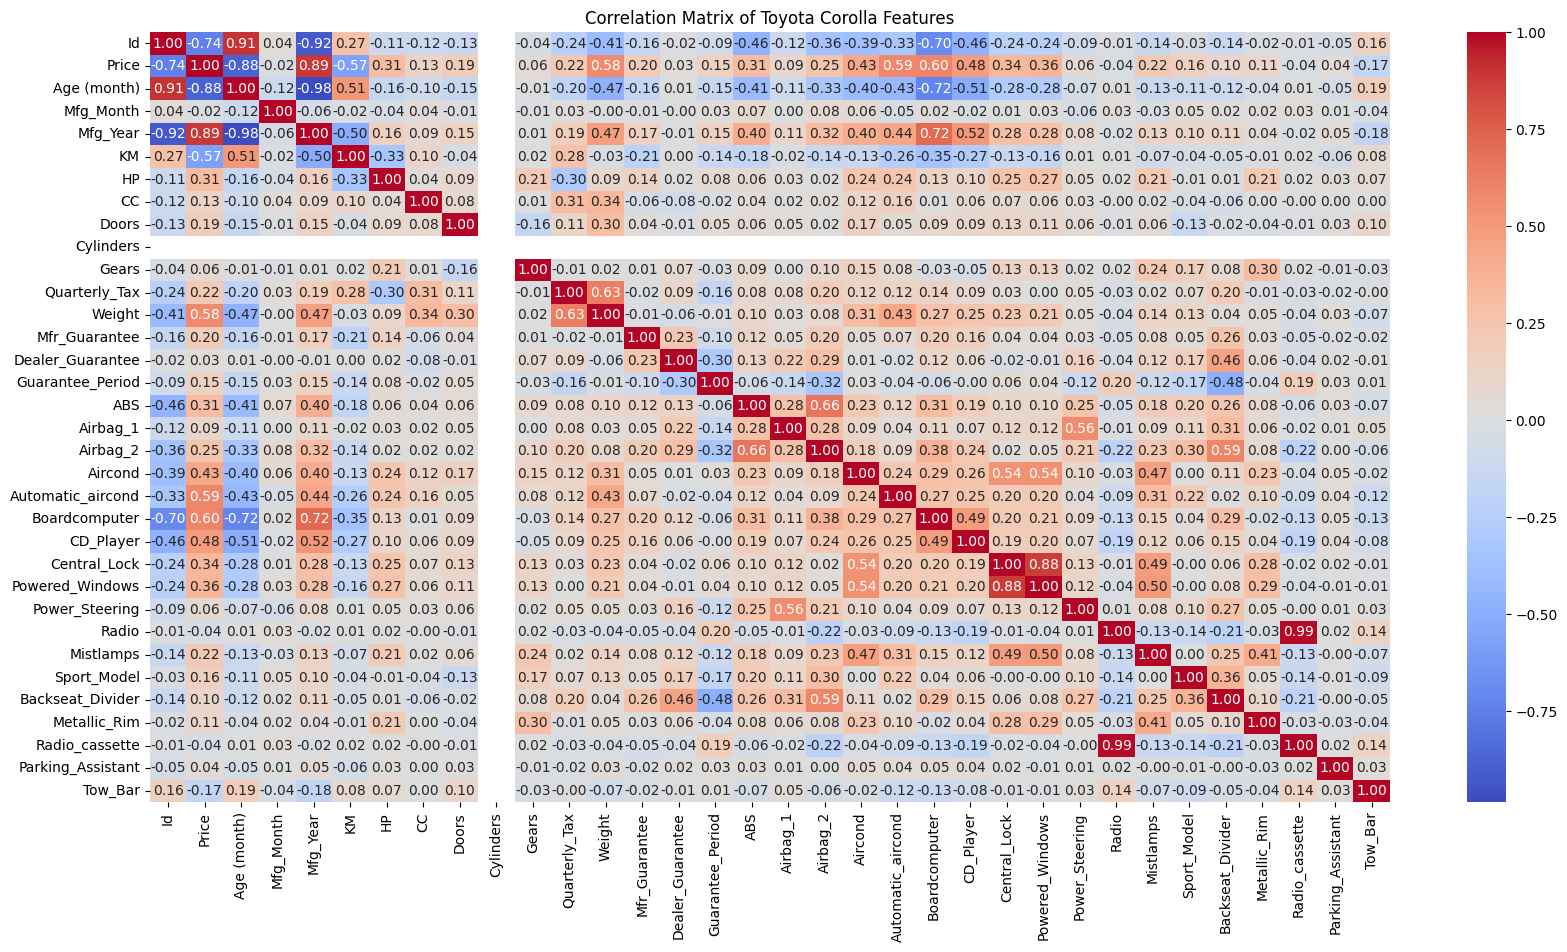

In [26]:
# prompt: produce a correlation matrix and matrix plot. Comment on the relationships among variables.

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # import pandas

# Assuming 'data_encoded' DataFrame from the previous code is available

# Calculate the correlation matrix
# Exclude non-numeric columns before calculating correlation
correlation_matrix = data_encoded.select_dtypes(include=['number']).corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(20, 10))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Toyota Corolla Features')
plt.show()

# Comment on the relationships among variables:
# Examine the heatmap to identify strong positive or negative correlations.
# Values close to 1 indicate a strong positive correlation.
# Values close to -1 indicate a strong negative correlation.
# Values close to 0 indicate a weak or no linear correlation.
# For example, you might observe strong correlations between Price and features like 'Age', 'KM', etc., as well as among dummy variables of the same feature.
# Explain the observed relationships in the context of the dataset, considering how different variables might influence each other.

               Price  Age (month)
Price        1.00000     -0.87659
Age (month) -0.87659      1.00000


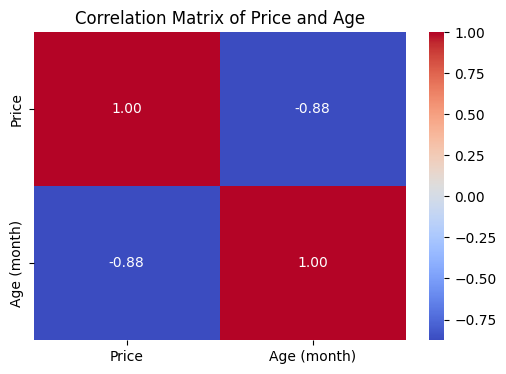

In [33]:
# prompt: coreration matrix  between price cand age

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'data_encoded' DataFrame from the previous code is available
# If not, load your data and perform the encoding as shown in the previous code

# Calculate the correlation matrix between 'Price' and 'Age'
correlation_matrix = data_encoded[['Price', 'Age (month)']].corr()

# Print the correlation matrix
print(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(6, 4))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Price and Age')
plt.show()
